#Deep Machine Learning: Summative assignment

Snehal Kawade (2595926)

**Topic: Drug-Target interaction Prediction**

davis kiba kaggle: [Davis-KIBA
A concise and classic DTA dataset](https://www.kaggle.com/datasets/christang0002/davis-and-kiba/data?select=kiba.txt)

##Import Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scipy.sparse as sp

import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor





import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")  # optional

In [ ]:
!pip install rdkit
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 22.7 MB/s eta 0:00:00


In [ ]:
!pip install xgboost
from xgboost import XGBRegressor

In [ ]:
# Define relevant file paths

kiba_path = '/content/drive/MyDrive/Colab Notebooks/End of Module assignment/kiba.txt'
davis_path = '/content/drive/MyDrive/Colab Notebooks/End of Module assignment/davis.txt'

MODEL_METRICS_PATH = "/content/drive/MyDrive/Colab Notebooks/End of Module assignment/model_metrics_global.csv"
PLOTS_BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/End of Module assignment/plots"

##Load Dataset

In [ ]:
kiba= pd.read_csv(kiba_path, sep= ' ', header = None) # Using space as the separator to match the file format
kiba.columns = ['drug', 'protein', 'smiles', 'sequence', 'score'] # Label each column

In [ ]:
kiba.head()

,drug,protein,smiles,sequence,score
0,CHEMBL1087421,O00141,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MTVKTEAAKGTLTYSRMRGMVAILIAFMKQRRMGLNDFIQKIANNS...,11.1
1,CHEMBL1087421,O14920,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MSWSPSLTTQTCGAWEMKERLGTGGFGNVIRWHNQETGEQIAIKQC...,11.1
2,CHEMBL1087421,O15111,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MERPPGLRPGAGGPWEMRERLGTGGFGNVCLYQHRELDLKIAIKSC...,11.1
3,CHEMBL1087421,P00533,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,11.1
4,CHEMBL1087421,P04626,COC1=C(C=C2C(=C1)CCN=C2C3=CC(=C(C=C3)Cl)Cl)Cl,MELAALCRWGLLLALLPPGAASTQVCTGTDMKLRLPASPETHLDML...,11.1


##Exploratory Data analysis

In [ ]:
kiba.info() #Total rows identified = 118254

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118254 entries, 0 to 118253
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   drug      118254 non-null  object 
 1   protein   118254 non-null  object 
 2   smiles    118254 non-null  object 
 3   sequence  118254 non-null  object 
 4   score     118254 non-null  float64
dtypes: float64(1), object(4)
memory usage: 4.5+ MB


In [ ]:
kiba.describe() #Range of the score is slightly skew

,score
count,118254.000000
mean,11.719935
std,0.836947
min,0.000000
25%,11.200000
50%,11.500000
75%,11.923909
max,17.200179


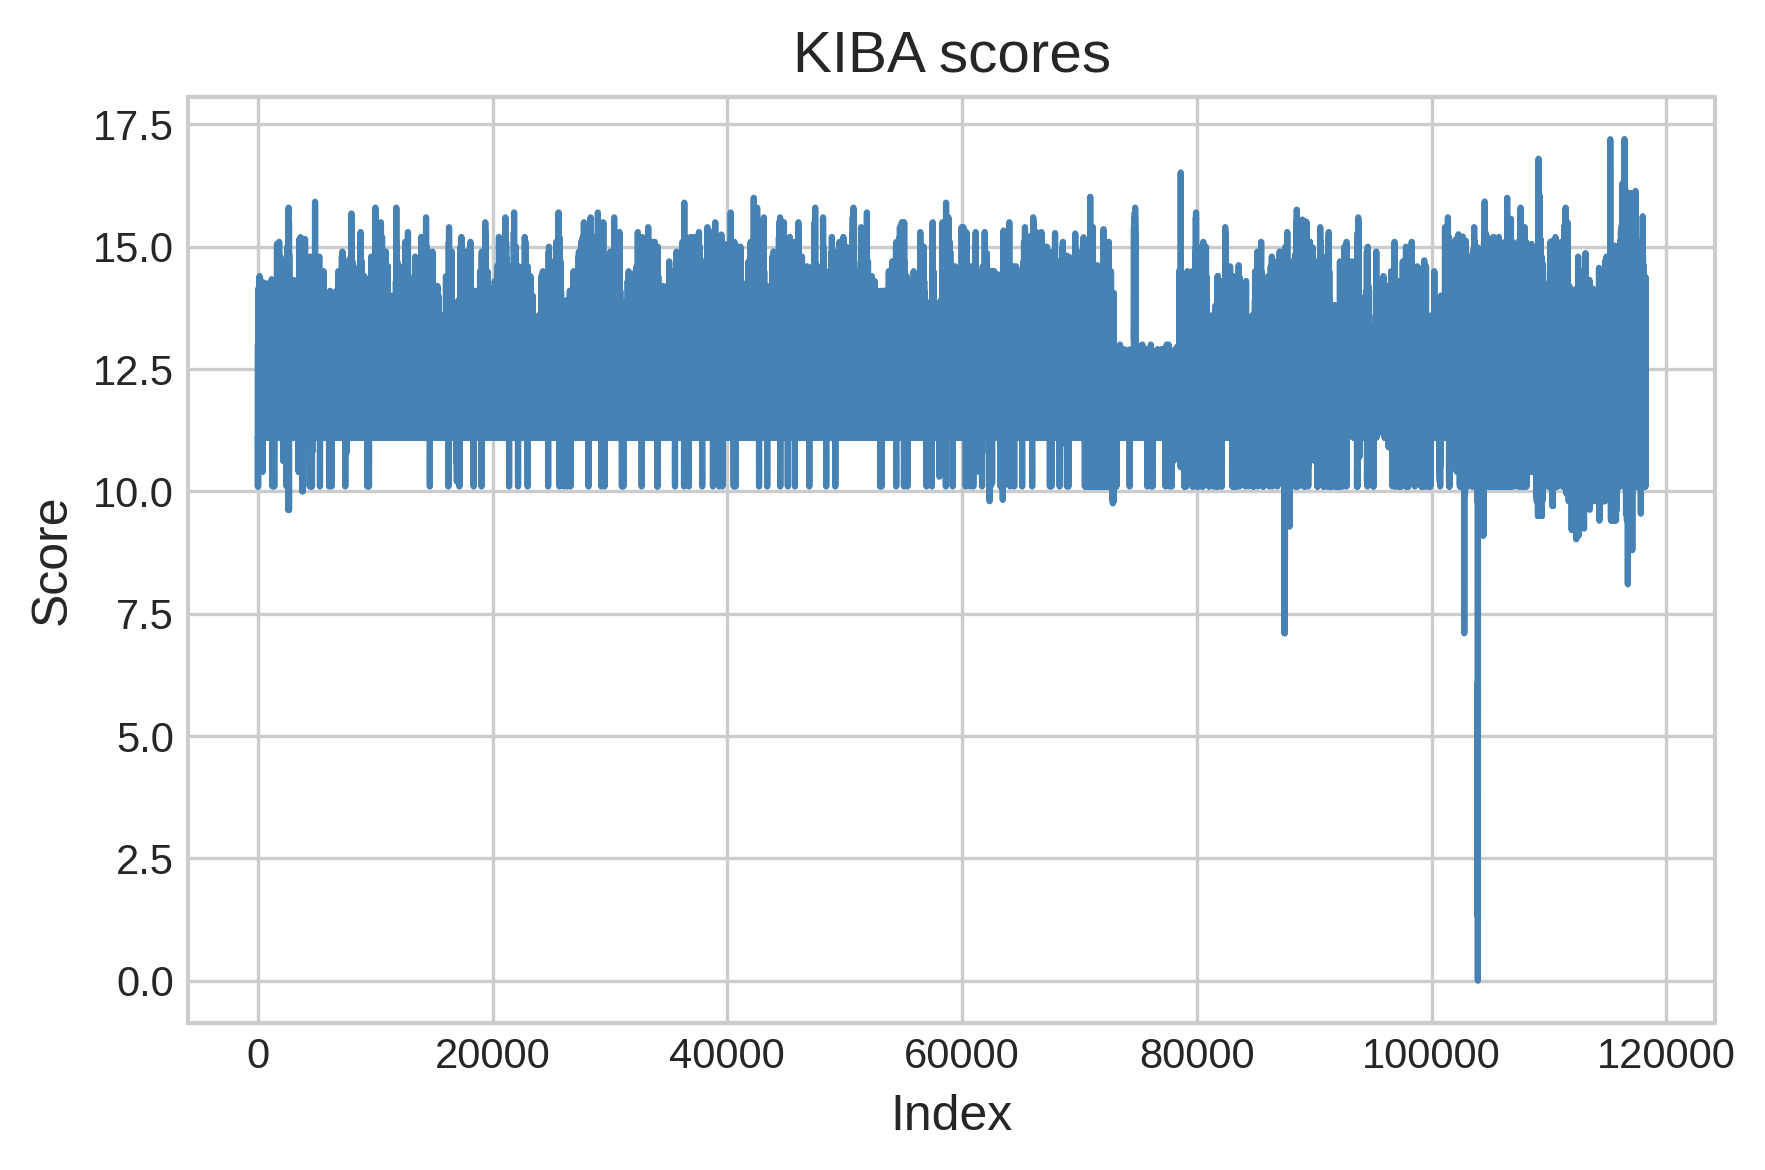

In [ ]:
# Check kiba score values

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
ax.plot(kiba['score'], color='steelblue')

ax.set_xlabel("Index", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("KIBA scores", fontsize=14)

fig.tight_layout()

filename = "kiba_scores_lineplot.png"
output_path = os.path.join(PLOTS_BASE_PATH, filename)
fig.savefig(output_path, dpi=300)



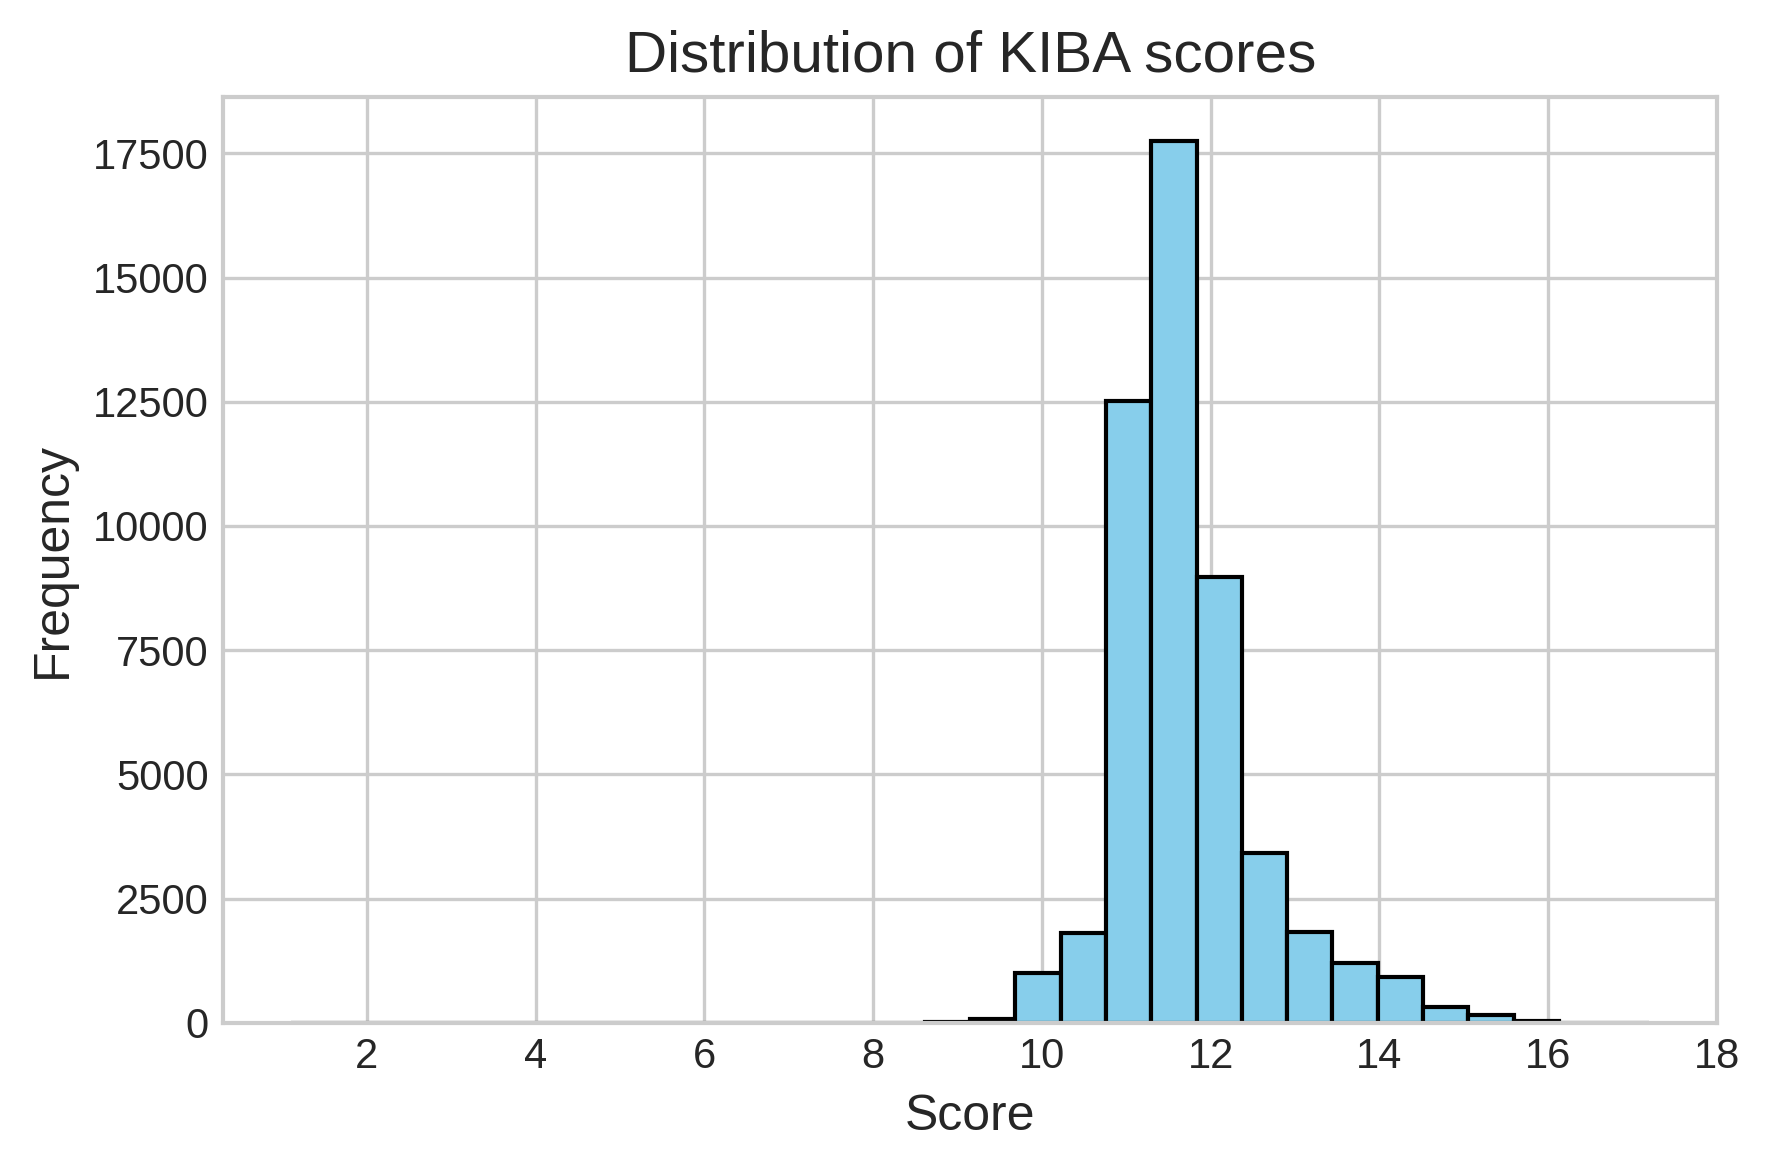

In [ ]:
# Check kiba score distribution

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
ax.hist(kiba['score'], color='skyblue', edgecolor='black', bins=30)


ax.set_xlabel("Score", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Distribution of KIBA scores", fontsize=14)

fig.tight_layout()

filename = "kiba_scores_histogram.png"
output_path = os.path.join(PLOTS_BASE_PATH, filename)
fig.savefig(output_path, dpi=300)




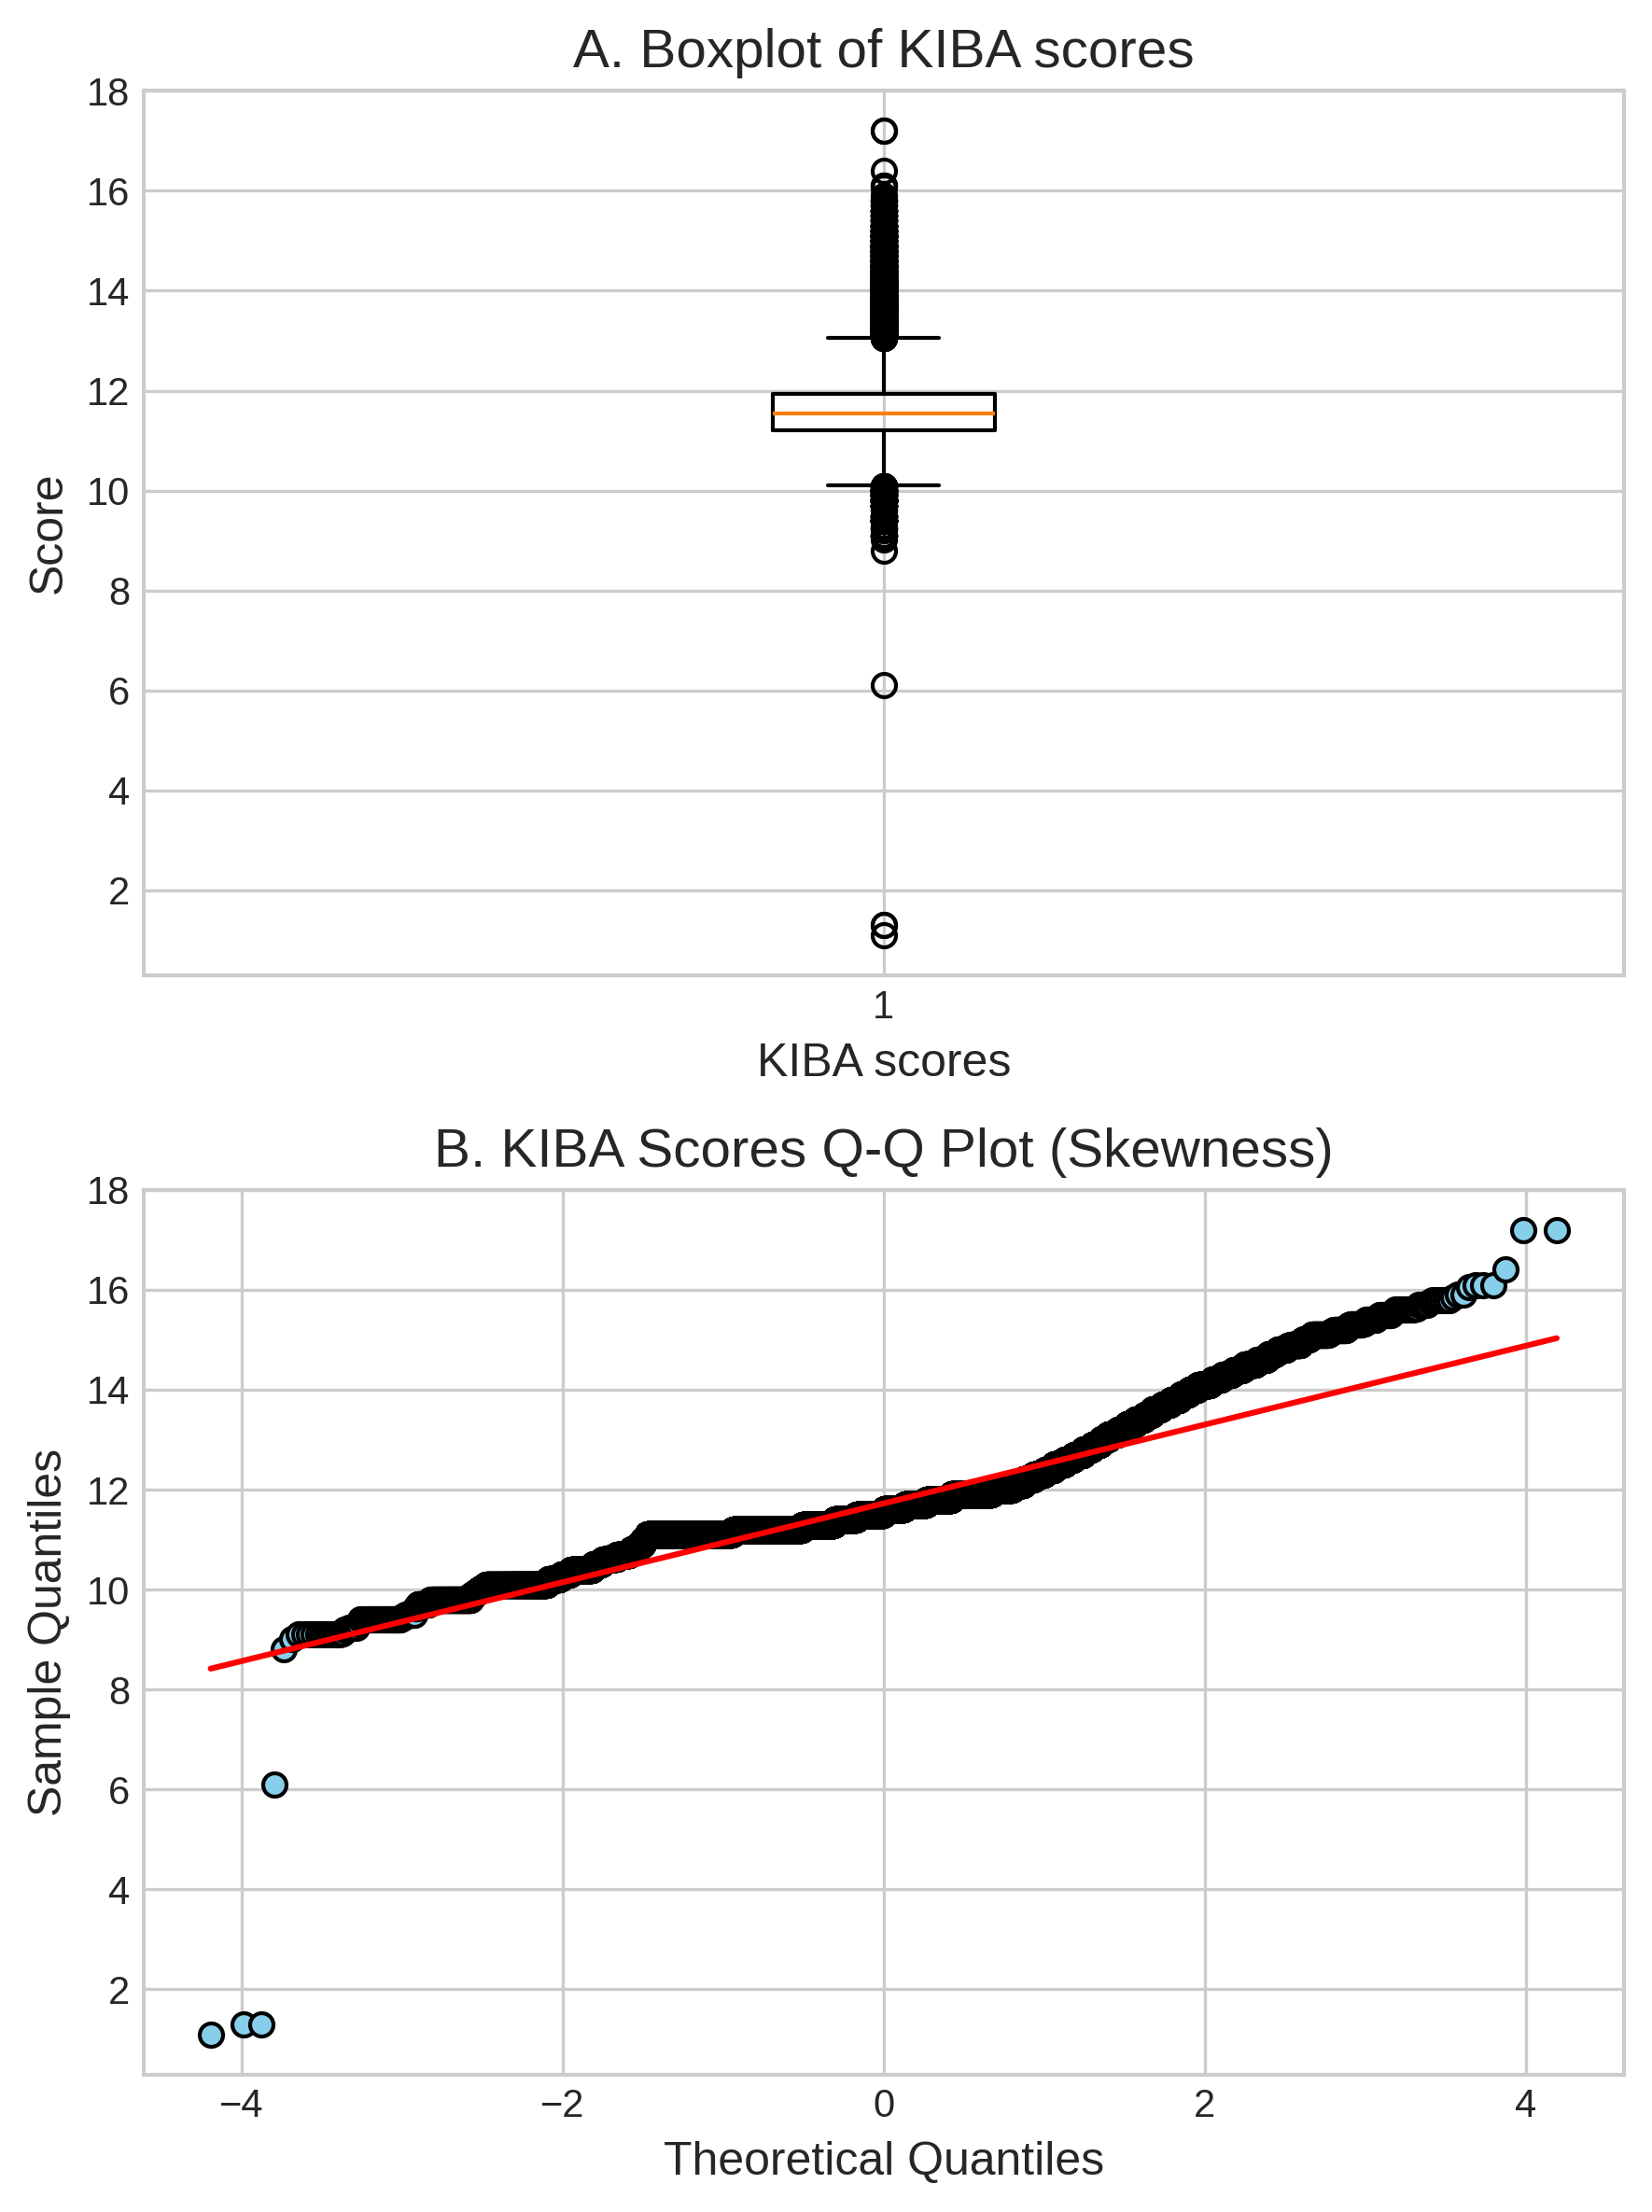

In [ ]:

# Create subplots: 2 rows, 1 column
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), dpi=300)

# Boxplot
ax1.boxplot(kiba['score'], vert=True, showfliers=True)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_xlabel('KIBA scores', fontsize=12)
ax1.set_title('A. Boxplot of KIBA scores', fontsize=14)

# Q-Q plot
stats.probplot(kiba['score'], dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('skyblue')
ax2.get_lines()[0].set_markeredgecolor('black')
ax2.set_xlabel("Theoretical Quantiles", fontsize=12)
ax2.set_ylabel("Sample Quantiles", fontsize=12)
ax2.set_title("B. KIBA Scores Q-Q Plot (Skewness)", fontsize=14)

fig.tight_layout()

filename = "kiba_scores_boxplot_qqplot.png"
output_path = os.path.join(PLOTS_BASE_PATH, filename)
fig.savefig(output_path, dpi=300)


In [ ]:
kiba['score'].describe()

,score
count,50000.000000
mean,11.723984
std,0.838919
min,1.100000
25%,11.200000
50%,11.543697
75%,11.941668
max,17.200179


## Dataset random sample

In [ ]:
# Get a random sample of 50000
# Using randon state 42 for reproducibility

kiba = kiba.sample(n=50_000, random_state=42)

In [ ]:
kiba.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 58637 to 112115
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   drug      50000 non-null  object 
 1   protein   50000 non-null  object 
 2   smiles    50000 non-null  object 
 3   sequence  50000 non-null  object 
 4   score     50000 non-null  float64
dtypes: float64(1), object(4)
memory usage: 2.3+ MB


In [ ]:
kiba.describe()

,score
count,50000.000000
mean,11.723984
std,0.838919
min,1.100000
25%,11.200000
50%,11.543697
75%,11.941668
max,17.200179


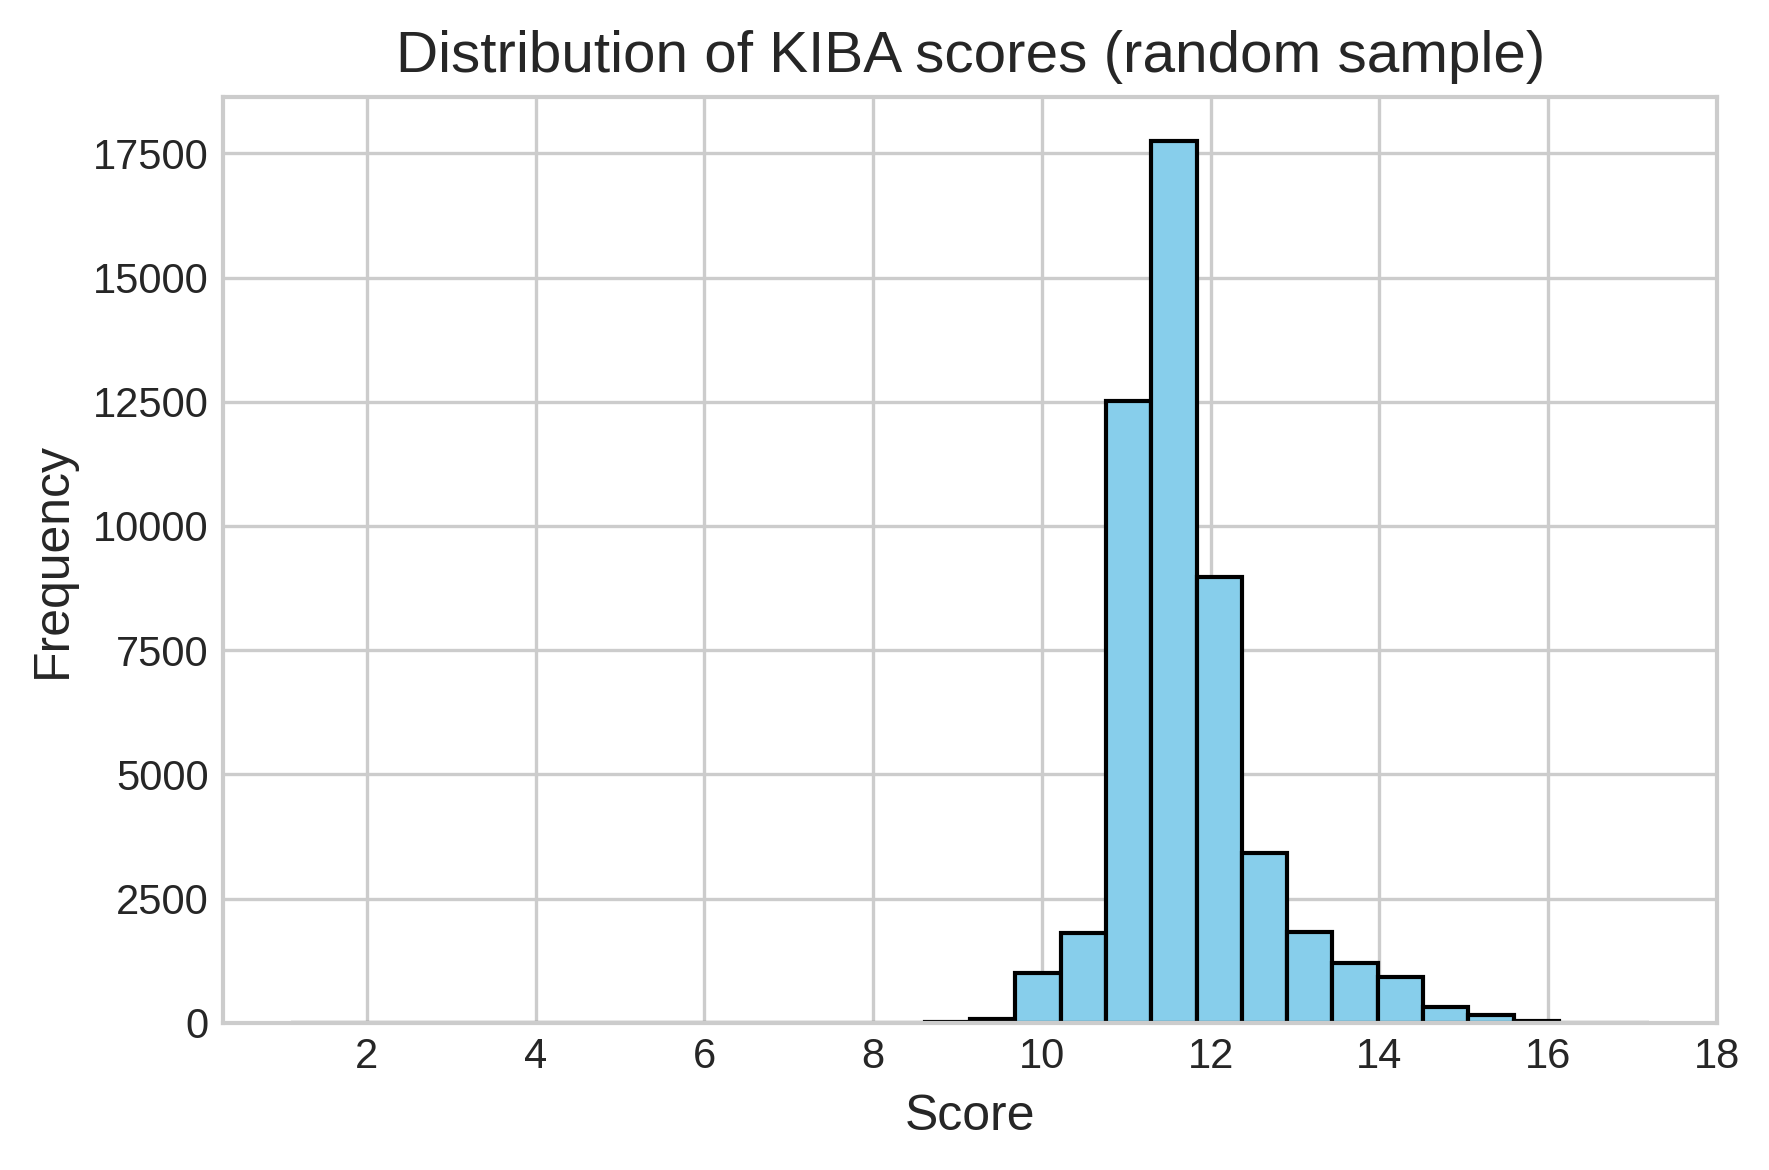

In [ ]:
# Recheck distribution of scores to verify that the subset is a relevant representative of the original dataset

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
ax.hist(kiba['score'], color='skyblue', edgecolor='black', bins=30)

ax.set_xlabel("Score", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Distribution of KIBA scores (random sample)", fontsize=14)

fig.tight_layout()

filename = "kiba_scores_histogram_random_sample.png"
output_path = os.path.join(PLOTS_BASE_PATH, filename)
fig.savefig(output_path, dpi=300)


In [ ]:
# Unique smiles and unique targets

unique_smiles = kiba['smiles'].nunique()
unique_targets = kiba['sequence'].nunique()

print(f"Unique SMILES: {unique_smiles}")
print(f"Unique Amino Acid Sequences: {unique_targets}")

Unique SMILES: 2067
Unique Amino Acid Sequences: 229


In [ ]:
# Check null values

kiba.isna().sum()

,0
drug,0
protein,0
smiles,0
sequence,0
score,0


##Feature Engineering : Transforming training data into a suitable format for the model use.

As a binary fingerprint (e.g. Morgan Fingerprint)

We have chosen to go ahead with Morgan Fingerprint to retain the structural information.

In [ ]:
smiles = kiba['smiles'][87]

In [ ]:
print(smiles)

C1COCCN1C2=CC(=CC=C2)NC3=NC=CC(=N3)C4=C(N=C5N4C=CS5)C6=CC(=CC=C6)NC(=O)CC7=CC=CC=C7


In [ ]:
print(smiles)

C1COCCN1C2=CC(=CC=C2)NC3=NC=CC(=N3)C4=C(N=C5N4C=CS5)C6=CC(=CC=C6)NC(=O)CC7=CC=CC=C7


In [ ]:
mol = Chem.MolFromSmiles(smiles) # 1. Convert SMILES to RDKit molecule

In [ ]:
print(mol)

We use the default values for radius and fpsize paramaters

In [ ]:
# 2. Convert Molecule to Morgan fingerprint (fixed length bit vector)

# Create a Morgan fingerprint generator
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

# Generate a bit vector fingerprint
fp = mfpgen.GetFingerprint(mol)

In [ ]:
print(fp)

In [ ]:
from rdkit import DataStructs

fp_array = np.zeros((1024,), dtype=int)
DataStructs.ConvertToNumpyArray(fp, fp_array)

In [ ]:
sum(fp_array)

np.int64(73)

The fingerprint bit vector is in fp (an RDKit ExplicitBitVect object).

The final numeric array we can use for ML is in fp_array, which is a NumPy array of length 1024

In [ ]:
# We define a separate function to perform the above steps
# The function returns the final numpy array


def generate_morgan_fingerprint(smiles, array_length =1024, radius =2):
    mol = Chem.MolFromSmiles(smiles)
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius= radius, fpSize= array_length)
    fp = mfpgen.GetFingerprint(mol)
    fp_array = np.zeros((array_length,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, fp_array)
    return fp_array

In [ ]:
# Testing the function

test = generate_morgan_fingerprint(smiles)

In [ ]:
for i, item in enumerate(test):
  if item == 1:
    print(i)

10
14
15
25
32
37
41
42
61
64
77
80
128
136
175
184
191
289
323
325
329
356
378
381
389
399
407
417
428
456
458
471
491
496
523
543
558
562
563
588
595
644
650
656
675
687
703
726
730
732
736
787
789
792
795
801
807
831
842
849
875
887
893
901
913
918
926
935
945
950
980
993
1014


In [ ]:
test = generate_morgan_fingerprint(smiles)

In [ ]:
for i, item in enumerate(test):
  if item == 1:
    print(i)

10
14
15
25
32
37
41
42
61
64
77
80
128
136
175
184
191
289
323
325
329
356
378
381
389
399
407
417
428
456
458
471
491
496
523
543
558
562
563
588
595
644
650
656
675
687
703
726
730
732
736
787
789
792
795
801
807
831
842
849
875
887
893
901
913
918
926
935
945
950
980
993
1014


In [ ]:
# Apply the function on the kiba smiles and save as a new column

kiba["smiles_num"] = kiba["smiles"].apply(lambda col:generate_morgan_fingerprint(col))

In [ ]:
kiba

,drug,protein,smiles,sequence,score,smiles_num
58637,CHEMBL2005475,Q9Y6M4,C1CCC(CC1)CNC(=O)C2=CC3=C(NN=C3S2)C4=CC=CC=C4,MENKKKDKDKSDDRMARPSGRSGHNTRGTGSSSSGVLMVGPNFRVG...,11.300000,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7623,CHEMBL185569,O96013,CC1=CC(=CC=C1)NC(=O)NC2=CC=C(C=C2)C3=C4CNC(=O)...,MFGKRKKRVEISAPSNFEHRVHTGFDQHEQKFTGLPRQWQSLIEES...,11.400000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
28019,CHEMBL1980142,Q13464,C1=CC2=C(C=CN=C2C(=C1)C(F)(F)F)NC(=O)NC3=CC=CC...,MSTGDSFETRFEKMDNLLRDPKSEVNSDCLLDGLDALVYDLDFPAL...,11.100000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
72021,CHEMBL1242477,P42345,CC(C)N1C2=C(C(=N1)C3=CC4=C(C=C3)C=NN4)C(=NC=N2)N,MLGTGPAAATTAATTSSNVSVLQQFASGLKSRNEETRAKAAKELQH...,12.020819,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
85578,CHEMBL2000685,P45983,CC(=NN=C(N)N)C1=CC(=CC(=C1)NC(=O)C2=CC(=CC=C2)...,MSRSKRDNNFYSVEIGDSTFTVLKRYQNLKPIGSGAQGIVCAAYDA...,11.800001,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...
34582,CHEMBL1985074,O15530,CSC1=CC2=C(C=C1)N=C3C(=C2Cl)CCNC3=O,MARTTSQLYDAVPIQSSVVLCSCPSPSMVRTQTESSTPPGIPGGSR...,11.500000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
115040,CHEMBL538718,O94806,CN1CC2CC3=C(C4=CC=CC=C4N3CC2C1)C5=C(C(=O)NC5=O...,MSANNSPPSAQKSVLPTAIPAVLPAASPCSSPKTGLSARLSNGSFS...,14.298970,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
7474,CHEMBL184847,O14757,CC1=C(C=C(C=C1)NC(=O)NC2=CC=C(C=C2)C3=C4CNC(=O...,MAVPFVEDWDLVQTLGEGAYGEVQLAVNRVTEEAVAVKIVDMKRAV...,11.200000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
30945,CHEMBL1982506,P17612,COC1=C(C=C2C(=C1)C=NC3=C2C(=O)NC3=O)OC,MGNAAAAKKGSEQESVKEFLAKAKEDFLKKWESPAQNTAHLDQFER...,11.200000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


Convert Amino acid sequence into numeric value for machine's better understanding

In [ ]:
sequence = kiba['sequence'][0]

In [ ]:
sequence

'MTVKTEAAKGTLTYSRMRGMVAILIAFMKQRRMGLNDFIQKIANNSYACKHPEVQSILKISQPQEPELMNANPSPPPSPSQQINLGPSSNPHAKPSDFHFLKVIGKGSFGKVLLARHKAEEVFYAVKVLQKKAILKKKEEKHIMSERNVLLKNVKHPFLVGLHFSFQTADKLYFVLDYINGGELFYHLQRERCFLEPRARFYAAEIASALGYLHSLNIVYRDLKPENILLDSQGHIVLTDFGLCKENIEHNSTTSTFCGTPEYLAPEVLHKQPYDRTVDWWCLGAVLYEMLYGLPPFYSRNTAEMYDNILNKPLQLKPNITNSARHLLEGLLQKDRTKRLGAKDDFMEIKSHVFFSLINWDDLINKKITPPFNPNVSGPNDLRHFDPEFTEEPVPNSIGKSPDSVLVTASVKEAAEAFLGFSYAPPTDSFL'

In [ ]:
# Defining a function to integer encode the amino acid requence

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"  # 20 standard AAs
aa_to_idx = {aa: i for i, aa in enumerate(AMINO_ACIDS)}

def seq_to_index_array(seq):
    indices = []
    for aa in seq:              # for each amino acid
        index = aa_to_idx[aa]   # look up its integer code
        indices.append(index)   # add to the list
    return np.array(indices, dtype=np.int32)

In [ ]:
aa_to_idx["H"]

6

In [ ]:
print(sequence)

MTVKTEAAKGTLTYSRMRGMVAILIAFMKQRRMGLNDFIQKIANNSYACKHPEVQSILKISQPQEPELMNANPSPPPSPSQQINLGPSSNPHAKPSDFHFLKVIGKGSFGKVLLARHKAEEVFYAVKVLQKKAILKKKEEKHIMSERNVLLKNVKHPFLVGLHFSFQTADKLYFVLDYINGGELFYHLQRERCFLEPRARFYAAEIASALGYLHSLNIVYRDLKPENILLDSQGHIVLTDFGLCKENIEHNSTTSTFCGTPEYLAPEVLHKQPYDRTVDWWCLGAVLYEMLYGLPPFYSRNTAEMYDNILNKPLQLKPNITNSARHLLEGLLQKDRTKRLGAKDDFMEIKSHVFFSLINWDDLINKKITPPFNPNVSGPNDLRHFDPEFTEEPVPNSIGKSPDSVLVTASVKEAAEAFLGFSYAPPTDSFL


In [ ]:
# Test the function

seq_to_index_array(sequence)

array([10, 16, 17,  8, 16,  3,  0,  0,  8,  5, 16,  9, 16, 19, 15, 14, 10,
       14,  5, 10, 17,  0,  7,  9,  7,  0,  4, 10,  8, 13, 14, 14, 10,  5,
        9, 11,  2,  4,  7, 13,  8,  7,  0, 11, 11, 15, 19,  0,  1,  8,  6,
       12,  3, 17, 13, 15,  7,  9,  8,  7, 15, 13, 12, 13,  3, 12,  3,  9,
       10, 11,  0, 11, 12, 15, 12, 12, 12, 15, 12, 15, 13, 13,  7, 11,  9,
        5, 12, 15, 15, 11, 12,  6,  0,  8, 12, 15,  2,  4,  6,  4,  9,  8,
       17,  7,  5,  8,  5, 15,  4,  5,  8, 17,  9,  9,  0, 14,  6,  8,  0,
        3,  3, 17,  4, 19,  0, 17,  8, 17,  9, 13,  8,  8,  0,  7,  9,  8,
        8,  8,  3,  3,  8,  6,  7, 10, 15,  3, 14, 11, 17,  9,  9,  8, 11,
       17,  8,  6, 12,  4,  9, 17,  5,  9,  6,  4, 15,  4, 13, 16,  0,  2,
        8,  9, 19,  4, 17,  9,  2, 19,  7, 11,  5,  5,  3,  9,  4, 19,  6,
        9, 13, 14,  3, 14,  1,  4,  9,  3, 12, 14,  0, 14,  4, 19,  0,  0,
        3,  7,  0, 15,  0,  9,  5, 19,  9,  6, 15,  9, 11,  7, 17, 19, 14,
        2,  9,  8, 12,  3

In [ ]:
# Apply the function on the kiba sequences and save as a new column

kiba["sequence_num"] = kiba["sequence"].apply(lambda col:seq_to_index_array(col))

In [ ]:
kiba

,drug,protein,smiles,sequence,score,smiles_num,sequence_num
58637,CHEMBL2005475,Q9Y6M4,C1CCC(CC1)CNC(=O)C2=CC3=C(NN=C3S2)C4=CC=CC=C4,MENKKKDKDKSDDRMARPSGRSGHNTRGTGSSSSGVLMVGPNFRVG...,11.300000,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[10, 3, 11, 8, 8, 8, 2, 8, 2, 8, 15, 2, 2, 14,..."
7623,CHEMBL185569,O96013,CC1=CC(=CC=C1)NC(=O)NC2=CC=C(C=C2)C3=C4CNC(=O)...,MFGKRKKRVEISAPSNFEHRVHTGFDQHEQKFTGLPRQWQSLIEES...,11.400000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[10, 4, 5, 8, 14, 8, 8, 14, 17, 3, 7, 15, 0, 1..."
28019,CHEMBL1980142,Q13464,C1=CC2=C(C=CN=C2C(=C1)C(F)(F)F)NC(=O)NC3=CC=CC...,MSTGDSFETRFEKMDNLLRDPKSEVNSDCLLDGLDALVYDLDFPAL...,11.100000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[10, 15, 16, 5, 2, 15, 4, 3, 16, 14, 4, 3, 8, ..."
72021,CHEMBL1242477,P42345,CC(C)N1C2=C(C(=N1)C3=CC4=C(C=C3)C=NN4)C(=NC=N2)N,MLGTGPAAATTAATTSSNVSVLQQFASGLKSRNEETRAKAAKELQH...,12.020819,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[10, 9, 5, 16, 5, 12, 0, 0, 0, 16, 16, 0, 0, 1..."
85578,CHEMBL2000685,P45983,CC(=NN=C(N)N)C1=CC(=CC(=C1)NC(=O)C2=CC(=CC=C2)...,MSRSKRDNNFYSVEIGDSTFTVLKRYQNLKPIGSGAQGIVCAAYDA...,11.800001,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[10, 15, 14, 15, 8, 14, 2, 11, 11, 4, 19, 15, ..."
...,...,...,...,...,...,...,...
34582,CHEMBL1985074,O15530,CSC1=CC2=C(C=C1)N=C3C(=C2Cl)CCNC3=O,MARTTSQLYDAVPIQSSVVLCSCPSPSMVRTQTESSTPPGIPGGSR...,11.500000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[10, 0, 14, 16, 16, 15, 13, 9, 19, 2, 0, 17, 1..."
115040,CHEMBL538718,O94806,CN1CC2CC3=C(C4=CC=CC=C4N3CC2C1)C5=C(C(=O)NC5=O...,MSANNSPPSAQKSVLPTAIPAVLPAASPCSSPKTGLSARLSNGSFS...,14.298970,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[10, 15, 0, 11, 11, 15, 12, 12, 15, 0, 13, 8, ..."
7474,CHEMBL184847,O14757,CC1=C(C=C(C=C1)NC(=O)NC2=CC=C(C=C2)C3=C4CNC(=O...,MAVPFVEDWDLVQTLGEGAYGEVQLAVNRVTEEAVAVKIVDMKRAV...,11.200000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[10, 0, 17, 12, 4, 17, 3, 2, 18, 2, 9, 17, 13,..."
30945,CHEMBL1982506,P17612,COC1=C(C=C2C(=C1)C=NC3=C2C(=O)NC3=O)OC,MGNAAAAKKGSEQESVKEFLAKAKEDFLKKWESPAQNTAHLDQFER...,11.200000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[10, 5, 11, 0, 0, 0, 0, 8, 8, 5, 15, 3, 13, 3,..."


We have converted smiles and sequences into numeric formats

Saving Kiba file into Kiba_transform to make it easy to read for next time.

In [ ]:
kiba_transform_path='/content/drive/MyDrive/Colab Notebooks/End of Module assignment/kiba_transform.csv'
kiba.to_csv(kiba_transform_path, index=False)

In [ ]:
# Save the raw ready‑to‑feature‑compute DataFrame
# Optional way to save the kiba transform file as pickle

kiba.to_pickle(kiba_transform_path)

In [ ]:
kiba.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 58637 to 112115
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   drug          50000 non-null  object 
 1   protein       50000 non-null  object 
 2   smiles        50000 non-null  object 
 3   sequence      50000 non-null  object 
 4   score         50000 non-null  float64
 5   smiles_num    50000 non-null  object 
 6   sequence_num  50000 non-null  object 
dtypes: float64(1), object(6)
memory usage: 4.1+ MB


## Prepare X and y as training columns and target column

In [ ]:
kiba.columns

Index(['drug', 'protein', 'smiles', 'sequence', 'score', 'smiles_num',
       'sequence_num'],
      dtype='object')

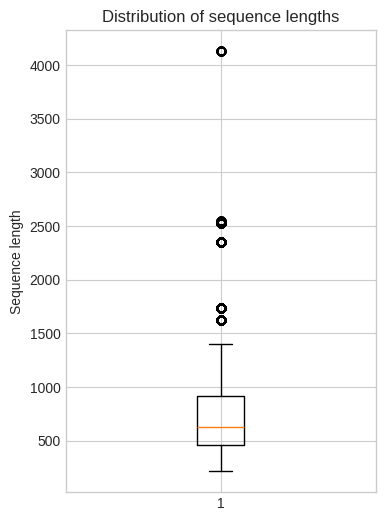

In [ ]:
# Quick test to check the general length of sequences.
# We assess the padding length for sequence num

# length of each sequence (number of elements in the list)
seq_lengths = kiba['sequence_num'].apply(len)

plt.figure(figsize=(4, 6))
plt.boxplot(seq_lengths, vert=True, showfliers=True)
plt.ylabel("Sequence length")
plt.title("Distribution of sequence lengths")
plt.show()

In [ ]:
# Using 95th quantile value to cover maximum sequences while ignoring the length for outliers
# The sequences with lengths greater than the 95th quantile will b etruncated

seq_lengths.quantile(0.95)

np.float64(1367.0)

In [ ]:
# Define functions for padding and building the feature matrix for input

import numpy as np

SMILES_LEN = 1024
SEQ_PAD_VALUE = 0

# function takes a variable‑length numeric sequence and returns a fixed‑length padded version of it
def pad_sequence(seq_vec, max_len):
    seq_vec = np.asarray(seq_vec, dtype=int)
    L = len(seq_vec)
    out = np.full((max_len,), SEQ_PAD_VALUE, dtype=int)
    # If the sequence is shorter than max_len, pad it, else truncate it
    out[:min(L, max_len)] = seq_vec[:max_len]
    return out



def build_feature_matrix(df, max_seq_len):
    X_list = []
    for _, row in df.iterrows():
        smi_vec = np.asarray(row['smiles_num'], dtype=float)   # length 1024
        seq_vec = pad_sequence(row['sequence_num'], max_seq_len)
        feat = np.concatenate([smi_vec, seq_vec], axis=0)      # 1024 + max_seq_len for the final concatenated input
        X_list.append(feat)

    # Stacking the smiles_num and sequence_num inputs as a col
    X = np.vstack(X_list)

    # free the X_list from memory after use
    del X_list
    return X


In [ ]:
# Important to select the best max_seq_length to avoid excessive length of padding
# max_seq_len = max(len(seq) for seq in kiba['sequence_num'])


max_seq_len = int(seq_lengths.quantile(0.95)) # 1367
X = build_feature_matrix(kiba, max_seq_len) # features
y = kiba['score'].values # target



In [ ]:
print("X shape:", X.shape)
print("X size GB:", X.nbytes / 1e9)


X shape: (50000, 2391)
X size GB: 0.9564


In [ ]:
print("length kiba: " + str(len(kiba)))
print("length sample sequence num: " + str(len(kiba['sequence_num'][20000])))


length kiba: 50000
length sample sequence num: 740


In [ ]:
max_seq_len

1367

In [ ]:
# Delete kiba from memory to save RAM

import gc
del kiba
gc.collect()

2921

## Save the X and y to memory

In [ ]:
# Optional, saved X and y to drive to continue in a different session

X_path='/content/drive/MyDrive/Colab Notebooks/End of Module assignment/X.npy'
y_path='/content/drive/MyDrive/Colab Notebooks/End of Module assignment/y.npy'

# np.save(X_path, X)      # ~4.9 GB
# np.save(y_path, y)

print("Saved X and y to disk")

Saved X and y to disk


## Dataset splits: x_train, y_train; x_test, y_test; x_validate, y_validate

Dataset is divided into parts to use for model training, validation and evaluation

In [ ]:
# To save memory/RAM, instead of splitting entire dataset, we use index values to perform the split

# Create an index
n = len(X)
idx = np.arange(n)

# First split: 80% train_full, 20% test
idx_train_full, idx_test = train_test_split(
    idx, test_size=0.2, random_state=42
)

# Second split (on train_full): 75% train, 25% val
idx_train, idx_val = train_test_split(
    idx_train_full, test_size=0.25, random_state=42,
)

# Slice original data into final sets using the indices
X_train = X[idx_train]
X_val   = X[idx_val]
X_test  = X[idx_test]
y_train = y[idx_train]
y_val   = y[idx_val]
y_test  = y[idx_test]

# Free X and y from memory to save RAM
import gc
del X, y
gc.collect()


0

In [ ]:
# Check shapes for training, validation and testing datasets

print("Train:", X_train.shape, y_train.shape) # 5152
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

Train: (30000, 2391) (30000,)
Val:   (10000, 2391) (10000,)
Test:  (10000, 2391) (10000,)


In [ ]:
# Optional: Save the splits for continuity of work in different sessions

# np.save("/content/drive/MyDrive/Colab Notebooks/End of Module assignment/X_train.npy", X_train)
# np.save("/content/drive/MyDrive/Colab Notebooks/End of Module assignment/X_val.npy",   X_val)
# np.save("/content/drive/MyDrive/Colab Notebooks/End of Module assignment/X_test.npy",  X_test)
# np.save("/content/drive/MyDrive/Colab Notebooks/End of Module assignment/y_train.npy", y_train)
# np.save("/content/drive/MyDrive/Colab Notebooks/End of Module assignment/y_val.npy",   y_val)
# np.save("/content/drive/MyDrive/Colab Notebooks/End of Module assignment/y_test.npy",  y_test)

## Dataset Batches

Dataset object creation for batches

In [ ]:
# Create dataset batches for ease of training and evaluation processes.

BATCH_SIZE = 50

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(BATCH_SIZE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

## Model 1: ANN

Basiv Artificial Neural Network

### Model Definition

In [ ]:
# Define a basic sequential neural network

model1 = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(2391,)),  # 2391 is a shape
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the model with optimizer and metrics

model1.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='mse',
    metrics=['mae', keras.metrics.RootMeanSquaredError()]
)

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       153,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,201 (606.25 KB)

 Trainable params: 155,201 (606.25 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [ ]:
# Using early stopping
early_stopping = keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True) # To avoid the model from overfitting

# Start training loop for the model
model1_history = model1.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=60,
    callbacks=[early_stopping]
)

Epoch 1/60
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 3.6172 - mae: 1.0469 - root_mean_squared_error: 1.6771 - val_loss: 0.5826 - val_mae: 0.5158 - val_root_mean_squared_error: 0.7633
Epoch 2/60
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.6481 - mae: 0.5802 - root_mean_squared_error: 0.8050 - val_loss: 0.6313 - val_mae: 0.6186 - val_root_mean_squared_error: 0.7945
Epoch 3/60
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.5850 - mae: 0.5450 - root_mean_squared_error: 0.7646 - val_loss: 0.6073 - val_mae: 0.5518 - val_root_mean_squared_error: 0.7793
Epoch 4/60
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.5678 - mae: 0.5444 - root_mean_squared_error: 0.7535 - val_loss: 0.5756 - val_mae: 0.5835 - val_root_mean_squared_error: 0.7587
Epoch 5/60
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.5754 - mae: 0.5533 - root_mean_squared_error: 0.7585 - val_loss: 0.6527 - val_mae: 0.5701 - val_root_mean_squared_error: 0.8079
Epoch 6/60
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/st

In [ ]:
model1_history.history

{'loss': [1.2786438465118408,
  0.6404747366905212,
  0.5772900581359863,
  0.5626391172409058,
  0.5698239803314209,
  0.5380256772041321,
  0.538284182548523,
  0.5414735674858093,
  0.5220342874526978,
  0.49541333317756653,
  0.5251425504684448,
  0.5088258981704712,
  0.5098347663879395,
  0.4967365562915802,
  0.4884170889854431,
  0.49214836955070496,
  0.4796156585216522,
  0.48406723141670227,
  0.4862956404685974,
  0.461628794670105,
  0.4607847332954407,
  0.4636911451816559,
  0.4530871510505676,
  0.4672492444515228,
  0.447951078414917,
  0.45064061880111694,
  0.4513382613658905,
  0.4497748017311096,
  0.43480542302131653,
  0.43984097242355347,
  0.4388771951198578,
  0.44029420614242554,
  0.4400818347930908,
  0.44494324922561646,
  0.4392727315425873,
  0.4281974732875824,
  0.4276154339313507,
  0.4279097318649292,
  0.4258247911930084,
  0.4247127175331116,
  0.4258706569671631,
  0.4237879812717438,
  0.4256027340888977,
  0.416349321603775,
  0.4185099303722381

In [ ]:
model1_history.history.keys()

dict_keys(['loss', 'mae', 'root_mean_squared_error', 'val_loss', 'val_mae', 'val_root_mean_squared_error'])

In [ ]:
# Extract all relevant metrics we need from the model training process

history = model1_history.history


# ----- Final Training Metrics -----
train_loss = history['loss'][-1]
train_mae = history['mae'][-1]
train_rmse = history['root_mean_squared_error'][-1]

print("Final Training Metrics:")
print(f"Loss: {train_loss}")
print(f"MAE: {train_mae}")
print(f"RMSE: {train_rmse}")




# ----- Final Validation Metrics -----
val_loss = history['val_loss'][-1]
val_mae = history['val_mae'][-1]
val_rmse = history['val_root_mean_squared_error'][-1]

print("\nFinal Validation Metrics:")
print(f"Val Loss: {val_loss}")
print(f"Val MAE: {val_mae}")
print(f"Val RMSE: {val_rmse}")


Final Training Metrics:
Loss: 0.4036256968975067
MAE: 0.44738665223121643
RMSE: 0.6353154182434082

Final Validation Metrics:
Val Loss: 0.46468716859817505
Val MAE: 0.5137289762496948
Val RMSE: 0.6816796660423279


Interpretation:
Model has learned a reasonable mapping (errors well below 1 score unit), and the training vs validation metrics are close, suggesting moderate overfitting at most and generally decent generalisation at this stage.

In [ ]:
# Optional, load X_test and y_test if in a new session

# X_test = np.load("/content/drive/MyDrive/Colab Notebooks/End of Module assignment/X_test.npy")
# y_test = np.load("/content/drive/MyDrive/Colab Notebooks/End of Module assignment/y_test.npy")

Create test dataset

In [ ]:
# Optional, create test_dataset if in a new session

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

### Model Evaluation

In [ ]:
# y_pred is calulated by evaluate function and it automatically gives the final metrics.
test_loss, test_mae, test_rmse = model1.evaluate(test_dataset)


print(f"Test Loss: {test_loss}")
print(f"Test MAE:  {test_mae}")
print(f"Test RMSE: {test_rmse}")

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4050 - mae: 0.4318 - root_mean_squared_error: 0.6360
Test Loss: 0.4056635797023773
Test MAE:  0.4325208365917206
Test RMSE: 0.636917233467102


In [ ]:
# Get predictions for the test set
# Doing the same prediction like evaluate but manually to get the y_pred values
y_pred = model1.predict(test_dataset)

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


### Save Model

In [ ]:
# Optional, save the model

# model1.save("/content/drive/MyDrive/Colab Notebooks/End of Module assignment/model1_ann_drug_protein_interaction.keras")


### Additional Evaluation metrics

In [ ]:
# R quared (R2) metric
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"r2:{r2}")
# Pearson and Spearman metrics
from scipy.stats import pearsonr, spearmanr
test_pearson, _ = pearsonr(y_test.flatten(), y_pred.flatten())
test_spearman, _ = spearmanr(y_test.flatten(), y_pred.flatten())

print(f"Pearson: {test_pearson}")
print(f"Spearman: {test_spearman}")

r2:0.42121039666294346
Pearson: 0.6496984500452927
Spearman: 0.6590518974645294


### Save metrics to dataframe

In [ ]:
# Save all metrics to dataframe

metrics_row = {
    'model_name': 'model1',
    'model_type': 'basic_ann',

    'train_loss': train_loss,
    'train_mae': train_mae,
    'train_rmse': train_rmse,

    'val_loss': val_loss,
    'val_mae': val_mae,
    'val_rmse': val_rmse,

    'test_loss': test_loss,
    'test_mae': test_mae,
    'test_rmse': test_rmse,

    'r2': r2,
    'pearson': test_pearson,
    'spearman': test_spearman
}

model_metrics = pd.DataFrame([metrics_row])

model_metrics

,model_name,model_type,train_loss,train_mae,train_rmse,val_loss,val_mae,val_rmse,test_loss,test_mae,test_rmse,r2,pearson,spearman
0,model1,basic_ann,0.403626,0.447387,0.635315,0.464687,0.513729,0.68168,0.405664,0.432521,0.636917,0.42121,0.649698,0.659052


In [ ]:
# Save metrics file to csv
model_metrics.to_csv(MODEL_METRICS_PATH, index=False)


## Model 2: CNN


Difference in Implementation: The CNN model expects drug and target inputs as separate arrays, instead of 1D concatenated. Therefore we prepare X and y with a new approach (specifically for this model)

### Prepare X and y as training columns and target column

In [ ]:
import numpy as np

SMILES_LEN = 1024
SEQ_PAD_VALUE = 0

# function takes a variable‑length numeric sequence and returns a fixed‑length padded version of it
def pad_sequence(seq_vec, max_len):
    seq_vec = np.asarray(seq_vec, dtype=int)
    L = len(seq_vec)
    out = np.full((max_len,), SEQ_PAD_VALUE, dtype=int)
    out[:min(L, max_len)] = seq_vec[:max_len]
    return out

def build_drug_and_protein_matrices(df, max_seq_len):
    drug_list = []
    prot_list = []

    for _, row in df.iterrows():
        # 1. Drug vector: Morgan fingerprint (already fixed length)
        smi_vec = np.asarray(row['smiles_num'], dtype=float)   # shape (1024,)

        # 2) Protein sequence: pad/truncate to max_seq_len
        seq_vec = pad_sequence(row['sequence_num'], max_seq_len)  # shape (max_seq_len,)

        drug_list.append(smi_vec)
        prot_list.append(seq_vec)

    # Keeping separate stacks for drug and protein(target) inputs

    X_drug = np.vstack(drug_list)    # shape: (n_samples, 1024)
    X_prot = np.vstack(prot_list)    # shape: (n_samples, max_seq_len)

    # free unnecessary variables and contents from memory to save RAM
    del drug_list, prot_list

    return X_drug, X_prot


In [ ]:
# max_seq_len = max(len(seq) for seq in kiba['sequence_num'])  # when using max value

# Instead we use 95th quantile value like we used in the previous data preprocessing
seq_lengths = kiba['sequence_num'].apply(len)
max_seq_len = int(seq_lengths.quantile(0.95)) # 1367

# Built the input Xs and output y variables
X_drug, X_prot = build_drug_and_protein_matrices(kiba, max_seq_len)
y = kiba['score'].values


In [ ]:
# Delete kiba from memory to save RAM

import gc
del kiba
gc.collect()

144

### Dataset splits: x_drug_train, x_prot_train, y_train; x_drug_test, x_prot_test, y_test; x_drug_validate, x_prot_validate, y_validate

Dataset is divided into parts to use for model training, validation and evaluation

In [ ]:
# Using indices to split the dataset

# create index
n_samples = len(y)
all_idx = np.arange(n_samples)

# 80% train+val, 20% test
train_val_idx, test_idx = train_test_split(
    all_idx, test_size=0.2, random_state=42, shuffle=True
)

# for train+val, take 75% train, 25% val. Overall split 60/20/20
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.25, random_state=42, shuffle=True
)

# Apply indices to both X_drug and X_prot, and y
X_drug_train, X_drug_val, X_drug_test = (
    X_drug[train_idx], X_drug[val_idx], X_drug[test_idx]
)
X_prot_train, X_prot_val, X_prot_test = (
    X_prot[train_idx], X_prot[val_idx], X_prot[test_idx]
)
y_train, y_val, y_test = (
    y[train_idx], y[val_idx], y[test_idx]
)

print("Train drug:", X_drug_train.shape, "prot:", X_prot_train.shape, "y:", y_train.shape)
print("Val   drug:", X_drug_val.shape,   "prot:", X_prot_val.shape,   "y:", y_val.shape)
print("Test  drug:", X_drug_test.shape,  "prot:", X_prot_test.shape,  "y:", y_test.shape)


Train drug: (30000, 1024) prot: (30000, 1367) y: (30000,)
Val   drug: (10000, 1024) prot: (10000, 1367) y: (10000,)
Test  drug: (10000, 1024) prot: (10000, 1367) y: (10000,)


### Dataset Batches

In [ ]:
# Create batches for datasets
# Input has 2 arrays this time, separated by comma

BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices(
    ((X_drug_train, X_prot_train), y_train)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    ((X_drug_val, X_prot_val), y_val)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices(
    ((X_drug_test, X_prot_test), y_test)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


### Model Definition

In [ ]:
# Pre define parameters for easy use

FINGERPRINT_DIM = X_drug_train.shape[1]   # 1024
MAX_SEQ_LEN = X_prot_train.shape[1]       # the same value chosen above, 95th quantile
AA_VOCAB_SIZE = int(X_prot_train.max()) + 1  # sequences are integer-coded AAs, use +1 for vocab size
EMBED_DIM = 16
DROPOUT_RATE = 0.3


In [ ]:
# We use 2 separate tower stuctures to process drug and protein inputs separately

# Drug tower
drug_net = models.Sequential([
    layers.Input(shape=(FINGERPRINT_DIM,)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(256, activation="relu"),
    layers.Dropout(DROPOUT_RATE),
], name="drug_net")

# Protein tower
prot_net = models.Sequential([
    layers.Input(shape=(MAX_SEQ_LEN,), dtype="int32"),
    layers.Embedding(input_dim=AA_VOCAB_SIZE,
                     output_dim=EMBED_DIM,
                     input_length=MAX_SEQ_LEN),
    layers.Conv1D(64, 7, activation="relu", padding="valid"),
    layers.GlobalMaxPooling1D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(DROPOUT_RATE),
], name="prot_net")


# Merge both towers into unified layers
drug_input = layers.Input(shape=(FINGERPRINT_DIM,), name="drug_input")
prot_input = layers.Input(shape=(MAX_SEQ_LEN,), dtype="int32", name="prot_input")

drug_repr = drug_net(drug_input)
prot_repr = prot_net(prot_input)

# Concatenate
x = layers.Concatenate()([drug_repr, prot_repr])
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(DROPOUT_RATE)(x)
x = layers.Dense(64, activation="relu")(x)
output = layers.Dense(1, name="affinity")(x)

model2 = models.Model(inputs=[drug_input, prot_input], outputs=output)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Compile model and check summary

model2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse"),
    ],
)

model2.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ drug_input          │ (None, 1024)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prot_input          │ (None, 1367)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drug_net            │ (None, 256)       │    328,192 │ drug_input[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prot_net            │ (None, 128)       │     15,872 │ prot_input[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ drug_net[0][0],   │
│ (Concatenate)       │                   │            │ prot_net[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ affinity (Dense)    │ (None, 1)         │         65 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 401,665 (1.53 MB)

 Trainable params: 401,665 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [ ]:
# Using early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

# Start model training
model2_history = model2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=60,
    callbacks=[early_stopping],
)



Epoch 1/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 111s 113ms/step - loss: 8.3780 - mae: 1.8316 - rmse: 2.5826 - val_loss: 5.4676 - val_mae: 2.2346 - val_rmse: 2.3383
Epoch 2/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 101s 107ms/step - loss: 1.4940 - mae: 0.9580 - rmse: 1.2220 - val_loss: 8.1942 - val_mae: 2.7780 - val_rmse: 2.8625
Epoch 3/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 98s 105ms/step - loss: 1.1051 - mae: 0.8132 - rmse: 1.0510 - val_loss: 6.0645 - val_mae: 2.3667 - val_rmse: 2.4626
Epoch 4/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 146s 109ms/step - loss: 0.8015 - mae: 0.6783 - rmse: 0.8951 - val_loss: 2.7073 - val_mae: 1.4996 - val_rmse: 1.6454
Epoch 5/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 136s 103ms/step - loss: 0.6155 - mae: 0.5747 - rmse: 0.7844 - val_loss: 1.3811 - val_mae: 0.9576 - val_rmse: 1.1752
Epoch 6/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 102s 109ms/step - loss: 0.5104 - mae: 0.5115 - rmse: 0.7143 - val_loss: 0.6497 - val_mae: 0.5205 - val_rmse: 0.8060
Epoch 7/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 141s 108ms/step - loss: 0

In [ ]:
# Extract training and validation metrics

history = model2_history.history


# ----- Final Training Metrics -----
train_loss = history['loss'][-1]
train_mae = history['mae'][-1]
train_rmse = history['rmse'][-1]

print("Final Training Metrics:")
print(f"Loss: {train_loss}")
print(f"MAE: {train_mae}")
print(f"RMSE: {train_rmse}")




# ----- Final Validation Metrics -----
val_loss = history['val_loss'][-1]
val_mae = history['val_mae'][-1]
val_rmse = history['val_rmse'][-1]

print("\nFinal Validation Metrics:")
print(f"Val Loss: {val_loss}")
print(f"Val MAE: {val_mae}")
print(f"Val RMSE: {val_rmse}")


Final Training Metrics:
Loss: 0.2983185350894928
MAE: 0.36014285683631897
RMSE: 0.5461854338645935

Final Validation Metrics:
Val Loss: 0.31565818190574646
Val MAE: 0.38590800762176514
Val RMSE: 0.5618346333503723


### Model Evaluation

In [ ]:
# y_pred is calulated by evaluate function and automatically gives the final metrics.
test_loss, test_mae, test_rmse = model2.evaluate(test_dataset)


print(f"Test Loss: {test_loss}")
print(f"Test MAE:  {test_mae}")
print(f"Test RMSE: {test_rmse}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.3091 - mae: 0.3772 - rmse: 0.5556
Test Loss: 0.31389933824539185
Test MAE:  0.37831878662109375
Test RMSE: 0.5602672100067139


In [ ]:
# Get predictions for the test set
# Doing the same prediction like evaluate but manually to get the y_pred values
y_pred = model2.predict(test_dataset)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


### Save Model

In [ ]:
# Optional: Save model
# model2.save("/content/drive/MyDrive/Colab Notebooks/End of Module assignment/model2_cnn_drug_protein_interaction.keras")


### Additional Evaluation metrics

In [ ]:
# R quared (R2) metric
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"r2:{r2}")
# Pearson and Spearman metrics
from scipy.stats import pearsonr, spearmanr
test_pearson, _ = pearsonr(y_test.flatten(), y_pred.flatten())
test_spearman, _ = spearmanr(y_test.flatten(), y_pred.flatten())

print(f"Pearson: {test_pearson}")
print(f"Spearman: {test_spearman}")

r2:0.5521370993772393
Pearson: 0.7497671900803581
Spearman: 0.7384847764393054


### Save metrics to dataframe

In [ ]:
# Save model metrics to the global metrics file and save

metrics_row = {
    'model_name': 'model2',
    'model_type': 'cnn',

    'train_loss': train_loss,
    'train_mae': train_mae,
    'train_rmse': train_rmse,

    'val_loss': val_loss,
    'val_mae': val_mae,
    'val_rmse': val_rmse,

    'test_loss': test_loss,
    'test_mae': test_mae,
    'test_rmse': test_rmse,

    'r2': r2,
    'pearson': test_pearson,
    'spearman': test_spearman
}

model_metrics = pd.read_csv(MODEL_METRICS_PATH)


model_metrics = pd.concat([model_metrics, pd.DataFrame([metrics_row])], ignore_index=True)


In [ ]:
model_metrics

,model_name,model_type,train_loss,train_mae,train_rmse,val_loss,val_mae,val_rmse,test_loss,test_mae,test_rmse,r2,pearson,spearman
0,model1,basic_ann,0.403626,0.447387,0.635315,0.464687,0.513729,0.681680,0.405664,0.432521,0.636917,0.421210,0.649698,0.659052
1,model2,cnn,0.298319,0.360143,0.546185,0.315658,0.385908,0.561835,0.313899,0.378319,0.560267,0.552137,0.749767,0.738485


In [ ]:
model_metrics.to_csv(MODEL_METRICS_PATH, index=False)


## Model 3: Linear Regression

### Model Definition

In [ ]:
# Define model

# Linear Regression
model3 = LinearRegression()

### Model Training

In [ ]:
model3.fit(X_train, y_train)


LinearRegression()

### Model Evaluation

In [ ]:
# Linear Regression model does not produce training metrics like neural networs
# For consistency, we manually produce trainig and validation metrics for model comparison

# Predictions
y_train_pred = model3.predict(X_train)
y_val_pred = model3.predict(X_val)
y_test_pred = model3.predict(X_test)



# Calculate metrics
train_loss = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_loss)

val_loss = mean_squared_error(y_val, y_val_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_loss)

test_loss = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_loss)



### Additional Evaluation metrics

In [ ]:
# R quared (R2) metric
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_test_pred)
print(f"r2:{r2}")
# Pearson and Spearman metrics
from scipy.stats import pearsonr, spearmanr
test_pearson, _ = pearsonr(y_test.flatten(), y_test_pred.flatten())
test_spearman, _ = spearmanr(y_test.flatten(), y_test_pred.flatten())

print(f"Pearson: {test_pearson}")
print(f"Spearman: {test_spearman}")

r2:0.40130662886964963
Pearson: 0.6362693223113178
Spearman: 0.6525444817105858


### Save metrics to dataframe

In [ ]:
# Save all model metrics
metrics_row = {
    'model_name': 'model3',
    'model_type': 'linear_regression',

    'train_loss': train_loss,
    'train_mae': train_mae,
    'train_rmse': train_rmse,

    'val_loss': val_loss,
    'val_mae': val_mae,
    'val_rmse': val_rmse,

    'test_loss': test_loss,
    'test_mae': test_mae,
    'test_rmse': test_rmse,

    'r2': r2,
    'pearson': test_pearson,
    'spearman': test_spearman
}

model_metrics = pd.read_csv(MODEL_METRICS_PATH)


model_metrics = pd.concat([model_metrics, pd.DataFrame([metrics_row])], ignore_index=True)


In [ ]:
model_metrics

,model_name,model_type,train_loss,train_mae,train_rmse,val_loss,val_mae,val_rmse,test_loss,test_mae,test_rmse,r2,pearson,spearman
0,model1,basic_ann,0.403626,0.447387,0.635315,0.464687,0.513729,0.681680,0.405664,0.432521,0.636917,0.421210,0.649698,0.659052
1,model2,cnn,0.298319,0.360143,0.546185,0.315658,0.385908,0.561835,0.313899,0.378319,0.560267,0.552137,0.749767,0.738485
2,model3,linear_regression,0.385930,0.427318,0.621233,0.419692,0.441470,0.647837,0.419614,0.444619,0.647776,0.401307,0.636269,0.652544


In [ ]:
model_metrics.to_csv(MODEL_METRICS_PATH, index=False)


## Model 4: Random Forest

### Model Definition

In [ ]:
# Define model with default hyperparameters

model4 = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1, # To use all available compute resource cores
    random_state=42,
    verbose=2
)

### Model Training

In [ ]:
# Start model training loop

model4.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 300building tree 2 of 300

building tree 3 of 300
building tree 4 of 300
building tree 5 of 300
building tree 6 of 300
building tree 7 of 300
building tree 8 of 300
building tree 9 of 300
building tree 10 of 300
building tree 11 of 300
building tree 12 of 300
building tree 13 of 300
building tree 14 of 300
building tree 15 of 300
building tree 16 of 300
building tree 17 of 300
building tree 18 of 300
building tree 19 of 300
building tree 20 of 300
building tree 21 of 300
building tree 22 of 300
building tree 23 of 300
building tree 24 of 300
building tree 25 of 300
building tree 26 of 300
building tree 27 of 300
building tree 28 of 300
building tree 29 of 300
building tree 30 of 300
building tree 31 of 300
building tree 32 of 300
building tree 33 of 300
building tree 34 of 300
building tree 35 of 300
building tree 36 of 300
building tree 37 of 300
building tree 38 of 300
building tree 39 of 300


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed: 11.8min


building tree 40 of 300
building tree 41 of 300
building tree 42 of 300
building tree 43 of 300
building tree 44 of 300
building tree 45 of 300
building tree 46 of 300
building tree 47 of 300
building tree 48 of 300
building tree 49 of 300
building tree 50 of 300
building tree 51 of 300
building tree 52 of 300
building tree 53 of 300
building tree 54 of 300
building tree 55 of 300
building tree 56 of 300
building tree 57 of 300
building tree 58 of 300
building tree 59 of 300
building tree 60 of 300
building tree 61 of 300
building tree 62 of 300
building tree 63 of 300
building tree 64 of 300
building tree 65 of 300
building tree 66 of 300
building tree 67 of 300
building tree 68 of 300
building tree 69 of 300
building tree 70 of 300
building tree 71 of 300
building tree 72 of 300
building tree 73 of 300
building tree 74 of 300
building tree 75 of 300
building tree 76 of 300
building tree 77 of 300
building tree 78 of 300
building tree 79 of 300
building tree 80 of 300
building tree 81

[Parallel(n_jobs=-1)]: Done 158 tasks      | elapsed: 48.1min


building tree 161 of 300
building tree 162 of 300
building tree 163 of 300
building tree 164 of 300
building tree 165 of 300
building tree 166 of 300
building tree 167 of 300
building tree 168 of 300
building tree 169 of 300
building tree 170 of 300
building tree 171 of 300
building tree 172 of 300
building tree 173 of 300
building tree 174 of 300
building tree 175 of 300
building tree 176 of 300
building tree 177 of 300
building tree 178 of 300
building tree 179 of 300
building tree 180 of 300
building tree 181 of 300
building tree 182 of 300
building tree 183 of 300
building tree 184 of 300
building tree 185 of 300
building tree 186 of 300
building tree 187 of 300
building tree 188 of 300
building tree 189 of 300
building tree 190 of 300
building tree 191 of 300
building tree 192 of 300
building tree 193 of 300
building tree 194 of 300
building tree 195 of 300
building tree 196 of 300
building tree 197 of 300
building tree 198 of 300
building tree 199 of 300
building tree 200 of 300


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed: 92.2min finished


RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42, verbose=2)

### Model Evaluation

In [ ]:
# Random Forest model does not produce training metrics like neural networs
# For consistency, we manually produce trainig and validation metrics for model comparison


# Predictions
y_train_pred = model4.predict(X_train)
y_val_pred = model4.predict(X_val)
y_test_pred = model4.predict(X_test)



# Calculate metrics
train_loss = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_loss)

val_loss = mean_squared_error(y_val, y_val_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_loss)

test_loss = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_loss)



[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.8s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    2.7s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    4.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    0.9s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    1.7s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    1.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    1.8s finished


### Additional Evaluation metrics

In [ ]:
# R quared (R2) metric
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_test_pred)
print(f"r2:{r2}")
# Pearson and Spearman metrics
from scipy.stats import pearsonr, spearmanr
test_pearson, _ = pearsonr(y_test.flatten(), y_test_pred.flatten())
test_spearman, _ = spearmanr(y_test.flatten(), y_test_pred.flatten())

print(f"Pearson: {test_pearson}")
print(f"Spearman: {test_spearman}")

r2:0.533075344927439
Pearson: 0.7376473713219096
Spearman: 0.7522693878525663


### Save metrics to dataframe

In [ ]:
# Save all model metrics

metrics_row = {
    'model_name': 'model4',
    'model_type': 'random_forest',

    'train_loss': train_loss,
    'train_mae': train_mae,
    'train_rmse': train_rmse,

    'val_loss': val_loss,
    'val_mae': val_mae,
    'val_rmse': val_rmse,

    'test_loss': test_loss,
    'test_mae': test_mae,
    'test_rmse': test_rmse,

    'r2': r2,
    'pearson': test_pearson,
    'spearman': test_spearman
}

model_metrics = pd.read_csv(MODEL_METRICS_PATH)


model_metrics = pd.concat([model_metrics, pd.DataFrame([metrics_row])], ignore_index=True)


In [ ]:
model_metrics

,model_name,model_type,train_loss,train_mae,train_rmse,val_loss,val_mae,val_rmse,test_loss,test_mae,test_rmse,r2,pearson,spearman
0,model1,basic_ann,0.403626,0.447387,0.635315,0.464687,0.513729,0.681680,0.405664,0.432521,0.636917,0.421210,0.649698,0.659052
1,model2,cnn,0.298319,0.360143,0.546185,0.315658,0.385908,0.561835,0.313899,0.378319,0.560267,0.552137,0.749767,0.738485
2,model3,linear_regression,0.385930,0.427318,0.621233,0.419692,0.441470,0.647837,0.419614,0.444619,0.647776,0.401307,0.636269,0.652544
3,model4,random_forest,0.046222,0.136152,0.214992,0.315201,0.357469,0.561428,0.327259,0.363574,0.572066,0.533075,0.737647,0.752269


In [ ]:
model_metrics.to_csv(MODEL_METRICS_PATH, index=False)


## Model 5: XGBoost

### Model Definition

In [ ]:
# Define model with hyperparameters

model5 = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42
)

### Model Training

In [ ]:
model5.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

### Model Evaluation

In [ ]:
# XGBoost model does not produce training metrics like neural networs
# For consistency, we manually produce trainig and validation metrics for model comparison


# Predictions
y_train_pred = model5.predict(X_train)
y_val_pred = model5.predict(X_val)
y_test_pred = model5.predict(X_test)



# Calculate metrics
train_loss = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_loss)

val_loss = mean_squared_error(y_val, y_val_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_loss)

test_loss = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_loss)



### Additional Evaluation metrics

In [ ]:
# R quared (R2) metric
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_test_pred)
print(f"r2:{r2}")
# Pearson and Spearman metrics
from scipy.stats import pearsonr, spearmanr
test_pearson, _ = pearsonr(y_test.flatten(), y_test_pred.flatten())
test_spearman, _ = spearmanr(y_test.flatten(), y_test_pred.flatten())

print(f"Pearson: {test_pearson}")
print(f"Spearman: {test_spearman}")

r2:0.6042234832356526
Pearson: 0.7816774700967735
Spearman: 0.7702521886146837


### Save metrics to dataframe

In [ ]:
# Save model metrics

metrics_row = {
    'model_name': 'model5',
    'model_type': 'xgboost',

    'train_loss': train_loss,
    'train_mae': train_mae,
    'train_rmse': train_rmse,

    'val_loss': val_loss,
    'val_mae': val_mae,
    'val_rmse': val_rmse,

    'test_loss': test_loss,
    'test_mae': test_mae,
    'test_rmse': test_rmse,

    'r2': r2,
    'pearson': test_pearson,
    'spearman': test_spearman
}

model_metrics = pd.read_csv(MODEL_METRICS_PATH)


model_metrics = pd.concat([model_metrics, pd.DataFrame([metrics_row])], ignore_index=True)


In [ ]:
model_metrics

,model_name,model_type,train_loss,train_mae,train_rmse,val_loss,val_mae,val_rmse,test_loss,test_mae,test_rmse,r2,pearson,spearman
0,model1,basic_ann,0.403626,0.447387,0.635315,0.464687,0.513729,0.681680,0.405664,0.432521,0.636917,0.421210,0.649698,0.659052
1,model2,cnn,0.298319,0.360143,0.546185,0.315658,0.385908,0.561835,0.313899,0.378319,0.560267,0.552137,0.749767,0.738485
2,model3,linear_regression,0.385930,0.427318,0.621233,0.419692,0.441470,0.647837,0.419614,0.444619,0.647776,0.401307,0.636269,0.652544
3,model4,random_forest,0.046222,0.136152,0.214992,0.315201,0.357469,0.561428,0.327259,0.363574,0.572066,0.533075,0.737647,0.752269
4,model5,xgboost,0.088376,0.208918,0.297281,0.273992,0.345569,0.523443,0.277393,0.346720,0.526681,0.604223,0.781677,0.770252


In [ ]:
model_metrics.to_csv(MODEL_METRICS_PATH, index=False)


## Model 6: Graph CNN

Graph CNN model requires 3 distict inputs, therefore we modify feature engineering and preprocessing (specifically for this model)

### Feature Engineering

In [ ]:
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
aa_to_idx = {aa: i+1 for i, aa in enumerate(AMINO_ACIDS)}

def seq_to_index_array(seq):
    indices = []
    for aa in seq:
        index = aa_to_idx.get(aa, 0)  # unknown AAs map to 0
        indices.append(index)
    return np.array(indices, dtype=np.int32)

In [ ]:
# Feature Engineering



ATOM_FEATURES = 5  # number of atom-level features we extract per node

# This function replaces generate_morgan_fingerprint()
# Returns: node feature matrix, shape (num_atoms, ATOM_FEATURES) and adjacency matrix, shape (num_atoms, num_atoms), scipy sparse

def smiles_to_graph(smiles):

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None

    # Node features: one row per atom
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append([
            atom.GetAtomicNum(),          # element (e.g. 6=Carbon, 7=Nitrogen)
            atom.GetDegree(),             # number of bonds
            atom.GetFormalCharge(),       # ionic charge
            int(atom.GetIsAromatic()),    # aromatic ring? 1/0
            int(atom.IsInRing()),         # in any ring? 1/0
        ])
    x = np.array(atom_features, dtype=np.float32)  # (num_atoms, 5)

    # Adjacency matrix: which atoms are bonded
    num_atoms = mol.GetNumAtoms()
    adj = np.zeros((num_atoms, num_atoms), dtype=np.float32)
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        adj[i, j] = 1.0
        adj[j, i] = 1.0  # undirected graph

    # Normalise adjacency (standard GCN trick: D^-0.5 * A * D^-0.5)
    # This prevents node embeddings from exploding with high-degree atoms
    degree = adj.sum(axis=1)
    d_inv_sqrt = np.where(degree > 0, 1.0 / np.sqrt(degree), 0.0)
    adj = adj * d_inv_sqrt[:, None] * d_inv_sqrt[None, :]

    adj_sparse = sp.csr_matrix(adj)  # store sparse to save memory

    return x, adj_sparse


# Apply to dataframe and create graphs
graphs = kiba["smiles"].apply(lambda s: smiles_to_graph(s))
kiba["graph_x"]   = graphs.apply(lambda g: g[0])  # node features
kiba["graph_adj"] = graphs.apply(lambda g: g[1])  # adjacency

# Protein processing remains the same
kiba["sequence_num"] = kiba["sequence"].apply(lambda col: seq_to_index_array(col))

/tmp/ipython-input-622/815393425.py:45: RuntimeWarning: divide by zero encountered in divide
  d_inv_sqrt = np.where(degree > 0, 1.0 / np.sqrt(degree), 0.0)


In [ ]:
# Check max atoms to cover maximum and avoid outlier values

atom_counts = kiba["graph_x"].apply(lambda x: x.shape[0])
print(atom_counts.describe())
print(f"90th percentile: {np.percentile(atom_counts, 90):.0f}")
print(f"95th percentile: {np.percentile(atom_counts, 95):.0f}")
print(f"99th percentile: {np.percentile(atom_counts, 99):.0f}")
print(f"Max: {atom_counts.max()}")

count    50000.000000
mean        27.269400
std          7.793823
min         10.000000
25%         23.000000
50%         27.000000
75%         31.000000
max        268.000000
Name: graph_x, dtype: float64
90th percentile: 36
95th percentile: 38
99th percentile: 46
Max: 268


### Prepare X and y as training columns and target column

In [ ]:
# MAX_ATOMS  = max(kiba["graph_x"].apply(lambda x: x.shape[0]))  # largest molecule
MAX_ATOMS = 50 # Truncating for the outlier, covering 99th percentile of molecule sizes

seq_lengths = kiba["sequence_num"].apply(len)
MAX_SEQ_LEN = int(seq_lengths.quantile(0.95)) # max(len(s) for s in kiba["sequence_num"])
SEQ_PAD_VALUE = 0


In [ ]:
# Padding & Batching
# Graphs can't be stacked like arrays because each molecule has a different
# number of atoms. We pad them


def pad_sequence(seq_vec, max_len):
    seq_vec = np.asarray(seq_vec, dtype=int)
    L = len(seq_vec)
    out = np.full((max_len,), SEQ_PAD_VALUE, dtype=int)
    out[:min(L, max_len)] = seq_vec[:max_len]
    return out

# Padding function for graphs
def pad_graph(x, adj, max_atoms):
    num_atoms = x.shape[0]

    # truncate if larger than max_atoms
    if num_atoms > max_atoms:
        x = x[:max_atoms, :]
        adj_dense = adj.toarray() if sp.issparse(adj) else adj
        adj_dense = adj_dense[:max_atoms, :max_atoms]
    else:
        adj_dense = adj.toarray() if sp.issparse(adj) else adj

    # pad node features
    x_pad = np.zeros((max_atoms, ATOM_FEATURES), dtype=np.float32)
    x_pad[:x.shape[0], :] = x

    # pad adjacency
    adj_pad = np.zeros((max_atoms, max_atoms), dtype=np.float32)
    adj_pad[:adj_dense.shape[0], :adj_dense.shape[0]] = adj_dense

    return x_pad, adj_pad

# Equivalent to the previous build_drug_and_protein_matrice function

def build_graph_and_protein_matrices(df, max_atoms, max_seq_len):

    X_node_list = []
    X_adj_list  = []
    X_prot_list = []

    for _, row in df.iterrows():
        x_pad, adj_pad = pad_graph(row["graph_x"], row["graph_adj"], max_atoms)
        seq_pad = pad_sequence(row["sequence_num"], max_seq_len)

        X_node_list.append(x_pad)
        X_adj_list.append(adj_pad)
        X_prot_list.append(seq_pad)

    X_node = np.stack(X_node_list)   # (n_samples, max_atoms, ATOM_FEATURES)
    X_adj  = np.stack(X_adj_list)    # (n_samples, max_atoms, max_atoms)
    X_prot = np.vstack(X_prot_list)  # (n_samples, max_seq_len)

    del X_node_list, X_adj_list, X_prot_list
    return X_node, X_adj, X_prot




In [ ]:
# Apply the functions to dataframe and create inputs Xs and output y

X_node, X_adj, X_prot = build_graph_and_protein_matrices(kiba, MAX_ATOMS, MAX_SEQ_LEN)
y = kiba["score"].values

In [ ]:
# Delete kiba from memory to save RAM

import gc
del kiba
gc.collect()

0

### Dataset splits: x_drug_train, x_prot_train, y_train; x_drug_test, x_prot_test, y_test; x_drug_validate, x_prot_validate, y_validate

Dataset is divided into parts to use for model training, validation and evaluation

In [ ]:
# Use indices to split datasets like we did in the previous sections

n_samples = len(y)
all_idx = np.arange(n_samples)

# 80% train+val, 20% test
train_val_idx, test_idx = train_test_split(
    all_idx, test_size=0.2, random_state=42, shuffle=True
)

# train+val - 75% train, 25% val. overall aplit 60/20/20
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.25, random_state=42, shuffle=True
)

# Node features
X_node_train, X_node_val, X_node_test = (
    X_node[train_idx], X_node[val_idx], X_node[test_idx]
)
# Adjacency matrices
X_adj_train, X_adj_val, X_adj_test = (
    X_adj[train_idx], X_adj[val_idx], X_adj[test_idx]
)
# Protein sequences
X_prot_train, X_prot_val, X_prot_test = (
    X_prot[train_idx], X_prot[val_idx], X_prot[test_idx]
)
y_train, y_val, y_test = (
    y[train_idx], y[val_idx], y[test_idx]
)
print("Train node:", X_node_train.shape, "adj:", X_adj_train.shape, "prot:", X_prot_train.shape, "y:", y_train.shape)
print("Val   node:", X_node_val.shape,   "adj:", X_adj_val.shape,   "prot:", X_prot_val.shape,   "y:", y_val.shape)
print("Test  node:", X_node_test.shape,  "adj:", X_adj_test.shape,  "prot:", X_prot_test.shape,  "y:", y_test.shape)

Train node: (30000, 50, 5) adj: (30000, 50, 50) prot: (30000, 1367) y: (30000,)
Val   node: (10000, 50, 5) adj: (10000, 50, 50) prot: (10000, 1367) y: (10000,)
Test  node: (10000, 50, 5) adj: (10000, 50, 50) prot: (10000, 1367) y: (10000,)


### Dataset Batches

In [ ]:
# Create dataset batches

BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices(
    ((X_node_train, X_adj_train, X_prot_train), y_train)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices(
    ((X_node_val, X_adj_val, X_prot_val), y_val)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices(
    ((X_node_test, X_adj_test, X_prot_test), y_test)
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

### Model Definition

In [ ]:
# GCN Layer (custom Keras layer)

import tensorflow as tf
from keras import layers, models

# Single graph convolution layer
# Operation: A * X * W  (adjacency-weighted aggregation + linear transform)
# A = normalised adjacency, X = node features, W = learnable weights
class GCNLayer(layers.Layer):

    def __init__(self, units, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        node_feature_dim = input_shape[0][-1]  # last dim of X
        self.W = self.add_weight(
            shape=(node_feature_dim, self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="W"
        )

    def call(self, inputs):
        X, A = inputs          # X: (batch, atoms, features)  A: (batch, atoms, atoms)
        XW = X @ self.W        # linear transform: (batch, atoms, units)
        AXW = A @ XW           # neighbourhood aggregation: (batch, atoms, units)
        return self.activation(AXW)

In [ ]:
# Model

# Define hyperparameters
DROPOUT_RATE = 0.2
GCN_UNITS    = 128
EMBED_DIM    = 128
AA_VOCAB_SIZE = 21   # 20 AAs + 0 padding index

# Drug tower: GCN over molecular graph
node_input = layers.Input(shape=(MAX_ATOMS, ATOM_FEATURES), name="node_input")
adj_input  = layers.Input(shape=(MAX_ATOMS, MAX_ATOMS),     name="adj_input")

gx = GCNLayer(GCN_UNITS, activation="relu")([node_input, adj_input])
gx = GCNLayer(GCN_UNITS, activation="relu")([gx, adj_input])      # second GCN layer
gx = layers.GlobalAveragePooling1D(name="graph_pool")(gx)          # (batch, GCN_UNITS)
gx = layers.Dense(128, activation="relu")(gx)
gx = layers.Dropout(DROPOUT_RATE)(gx)
drug_repr = gx

# Protein tower: similar to CNN model 2
prot_input = layers.Input(shape=(MAX_SEQ_LEN,), dtype="int32", name="prot_input")
px = layers.Embedding(input_dim=AA_VOCAB_SIZE,
                      output_dim=EMBED_DIM,
                      input_length=MAX_SEQ_LEN)(prot_input)
px = layers.Conv1D(64, 7, activation="relu", padding="valid")(px)
px = layers.GlobalMaxPooling1D()(px)
px = layers.Dense(128, activation="relu")(px)
px = layers.Dropout(DROPOUT_RATE)(px)
prot_repr = px

# Merge and concatenate
x = layers.Concatenate()([drug_repr, prot_repr])
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(DROPOUT_RATE)(x)
x = layers.Dense(64, activation="relu")(x)
output = layers.Dense(1, name="affinity")(x)

model6 = models.Model(inputs=[node_input, adj_input, prot_input], outputs=output)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model6.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse"),
    ],
)

model6.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ node_input          │ (None, 50, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adj_input           │ (None, 50, 50)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prot_input          │ (None, 1367)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gcn_layer           │ (None, 50, 128)   │        640 │ node_input[0][0], │
│ (GCNLayer)          │                   │            │ adj_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1367, 128) │      2,688 │ prot_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gcn_layer_1         │ (None, 50, 128)   │     16,384 │ gcn_layer[0][0],  │
│ (GCNLayer)          │                   │            │ adj_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1361, 64)  │     57,408 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ graph_pool          │ (None, 128)       │          0 │ gcn_layer_1[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ graph_pool[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      8,320 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ affinity (Dense)    │ (None, 1)         │         65 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 143,169 (559.25 KB)

 Trainable params: 143,169 (559.25 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [ ]:
# Model training loop

model6_history = model6.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    ]
)


Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 444s 469ms/step - loss: 7.8303 - mae: 1.7151 - rmse: 2.4753 - val_loss: 2.6157 - val_mae: 1.4291 - val_rmse: 1.6173
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 431s 460ms/step - loss: 1.2709 - mae: 0.8666 - rmse: 1.1271 - val_loss: 6.0082 - val_mae: 2.3272 - val_rmse: 2.4512
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 436s 453ms/step - loss: 1.0312 - mae: 0.7635 - rmse: 1.0154 - val_loss: 8.8081 - val_mae: 2.8675 - val_rmse: 2.9678
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 419s 447ms/step - loss: 0.8816 - mae: 0.6950 - rmse: 0.9389 - val_loss: 7.1978 - val_mae: 2.5721 - val_rmse: 2.6829
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 422s 450ms/step - loss: 0.8205 - mae: 0.6637 - rmse: 0.9057 - val_loss: 5.8972 - val_mae: 2.3057 - val_rmse: 2.4284
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 434s 463ms/step - loss: 0.7641 - mae: 0.6322 - rmse: 0.8741 - val_loss: 4.4936 - val_mae: 1.9772 - val_rmse: 2.1198
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 433s 461ms/step - loss: 

### Model Evaluation

In [ ]:
# y_pred is calulated by evaluate function and automatically gives the final metrics.
test_loss, test_mae, test_rmse = model6.evaluate(test_dataset)


print(f"Test Loss: {test_loss}")
print(f"Test MAE:  {test_mae}")
print(f"Test RMSE: {test_rmse}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - loss: 0.4831 - mae: 0.4851 - rmse: 0.6948
Test Loss: 0.4738907814025879
Test MAE:  0.48096635937690735
Test RMSE: 0.688397228717804


In [ ]:
# Predictions
y_test_pred = model6.predict(test_dataset)

313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 199ms/step


In [ ]:
# Extract model metrics

history = model6_history.history


# ----- Final Training Metrics -----
train_loss = history['loss'][-1]
train_mae = history['mae'][-1]
train_rmse = history['rmse'][-1]

print("Final Training Metrics:")
print(f"Loss: {train_loss}")
print(f"MAE: {train_mae}")
print(f"RMSE: {train_rmse}")




# ----- Final Validation Metrics -----
val_loss = history['val_loss'][-1]
val_mae = history['val_mae'][-1]
val_rmse = history['val_rmse'][-1]

print("\nFinal Validation Metrics:")
print(f"Val Loss: {val_loss}")
print(f"Val MAE: {val_mae}")
print(f"Val RMSE: {val_rmse}")


Final Training Metrics:
Loss: 0.48038554191589355
MAE: 0.4680337905883789
RMSE: 0.6930984854698181

Final Validation Metrics:
Val Loss: 0.4571772515773773
Val MAE: 0.46499788761138916
Val RMSE: 0.6761488318443298


### Additional Evaluation metrics

In [ ]:
# R quared (R2) metric
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_test_pred)
print(f"r2:{r2}")
# Pearson and Spearman metrics
from scipy.stats import pearsonr, spearmanr
test_pearson, _ = pearsonr(y_test.flatten(), y_test_pred.flatten())
test_spearman, _ = spearmanr(y_test.flatten(), y_test_pred.flatten())

print(f"Pearson: {test_pearson}")
print(f"Spearman: {test_spearman}")

r2:0.32386538387356
Pearson: 0.5776320644637334
Spearman: 0.6013259252226429


### Save metrics to dataframe

In [ ]:
# Save model metrics

metrics_row = {
    'model_name': 'model6',
    'model_type': 'gcn_cnn',

    'train_loss': train_loss,
    'train_mae': train_mae,
    'train_rmse': train_rmse,

    'val_loss': val_loss,
    'val_mae': val_mae,
    'val_rmse': val_rmse,

    'test_loss': test_loss,
    'test_mae': test_mae,
    'test_rmse': test_rmse,

    'r2': r2,
    'pearson': test_pearson,
    'spearman': test_spearman
}

model_metrics = pd.read_csv(MODEL_METRICS_PATH)

# When adding more models later:
model_metrics = pd.concat([model_metrics, pd.DataFrame([metrics_row])], ignore_index=True)


In [ ]:
model_metrics

,model_name,model_type,train_loss,train_mae,train_rmse,val_loss,val_mae,val_rmse,test_loss,test_mae,test_rmse,r2,pearson,spearman
0,model1,basic_ann,0.403626,0.447387,0.635315,0.464687,0.513729,0.681680,0.405664,0.432521,0.636917,0.421210,0.649698,0.659052
1,model2,cnn,0.298319,0.360143,0.546185,0.315658,0.385908,0.561835,0.313899,0.378319,0.560267,0.552137,0.749767,0.738485
2,model3,linear_regression,0.385930,0.427318,0.621233,0.419692,0.441470,0.647837,0.419614,0.444619,0.647776,0.401307,0.636269,0.652544
3,model4,random_forest,0.046222,0.136152,0.214992,0.315201,0.357469,0.561428,0.327259,0.363574,0.572066,0.533075,0.737647,0.752269
4,model5,xgboost,0.088376,0.208918,0.297281,0.273992,0.345569,0.523443,0.277393,0.346720,0.526681,0.604223,0.781677,0.770252
5,model6,gcn_cnn,0.480386,0.468034,0.693098,0.457177,0.464998,0.676149,0.473891,0.480966,0.688397,0.323865,0.577632,0.601326


In [ ]:
model_metrics.to_csv(MODEL_METRICS_PATH, index=False)


## Model Comparison

In [ ]:
model_metrics = pd.read_csv(MODEL_METRICS_PATH)
model_metrics

,model_name,model_type,train_loss,train_mae,train_rmse,val_loss,val_mae,val_rmse,test_loss,test_mae,test_rmse,r2,pearson,spearman
0,model1,basic_ann,0.403626,0.447387,0.635315,0.464687,0.513729,0.681680,0.405664,0.432521,0.636917,0.421210,0.649698,0.659052
1,model2,cnn,0.298319,0.360143,0.546185,0.315658,0.385908,0.561835,0.313899,0.378319,0.560267,0.552137,0.749767,0.738485
2,model3,linear_regression,0.385930,0.427318,0.621233,0.419692,0.441470,0.647837,0.419614,0.444619,0.647776,0.401307,0.636269,0.652544
3,model4,random_forest,0.046222,0.136152,0.214992,0.315201,0.357469,0.561428,0.327259,0.363574,0.572066,0.533075,0.737647,0.752269
4,model5,xgboost,0.088376,0.208918,0.297281,0.273992,0.345569,0.523443,0.277393,0.346720,0.526681,0.604223,0.781677,0.770252
5,model6,gcn_cnn,0.480386,0.468034,0.693098,0.457177,0.464998,0.676149,0.473891,0.480966,0.688397,0.323865,0.577632,0.601326


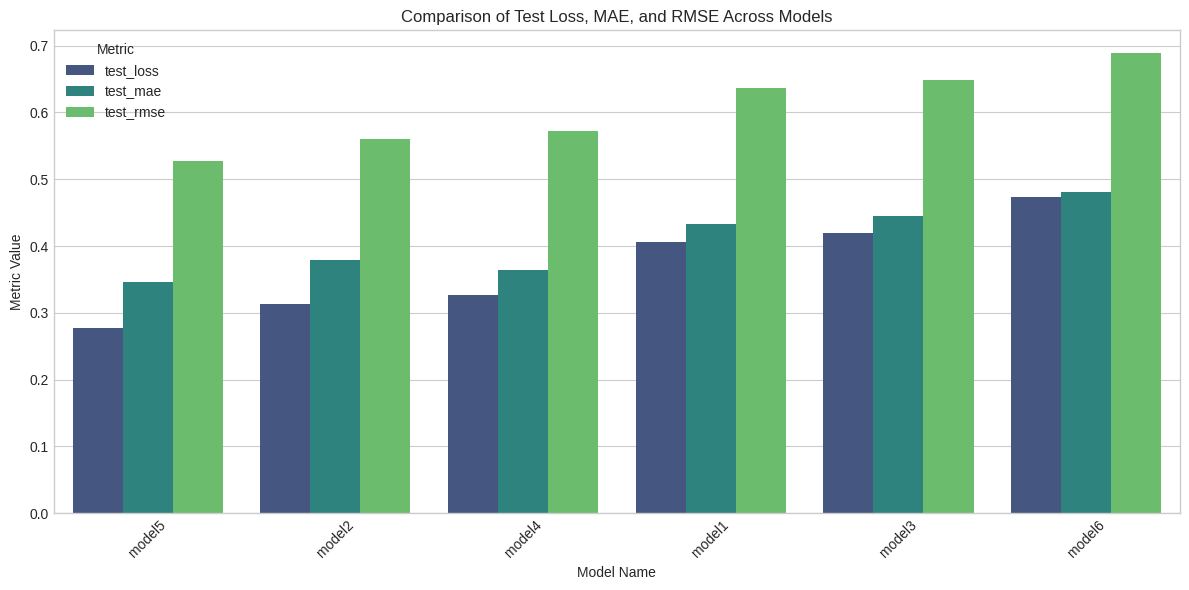

In [ ]:
# Test Loss, Test MAE, Test RMSE

# Sort by test_loss for ordering
metrics_for_plot1 = ['model_name', 'test_loss', 'test_mae', 'test_rmse']
df_plot1 = model_metrics[metrics_for_plot1].sort_values(by='test_loss', ascending=True)

# Melt the DataFrame
df_plot1_melted = df_plot1.melt(id_vars='model_name', var_name='Metric', value_name='Value')

fig1, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(x='model_name', y='Value', hue='Metric', data=df_plot1_melted, ax=ax1, palette='viridis')
ax1.set_title('Comparison of Test Loss, MAE, and RMSE Across Models')
ax1.set_xlabel('Model Name')
ax1.set_ylabel('Metric Value')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Metric')
fig1.tight_layout()

# Save plot
filename1 = "model_metrics_loss_mae_rmse_comparison.png"
output_path1 = os.path.join(PLOTS_BASE_PATH, filename1)
fig1.savefig(output_path1, dpi=300)
plt.show()

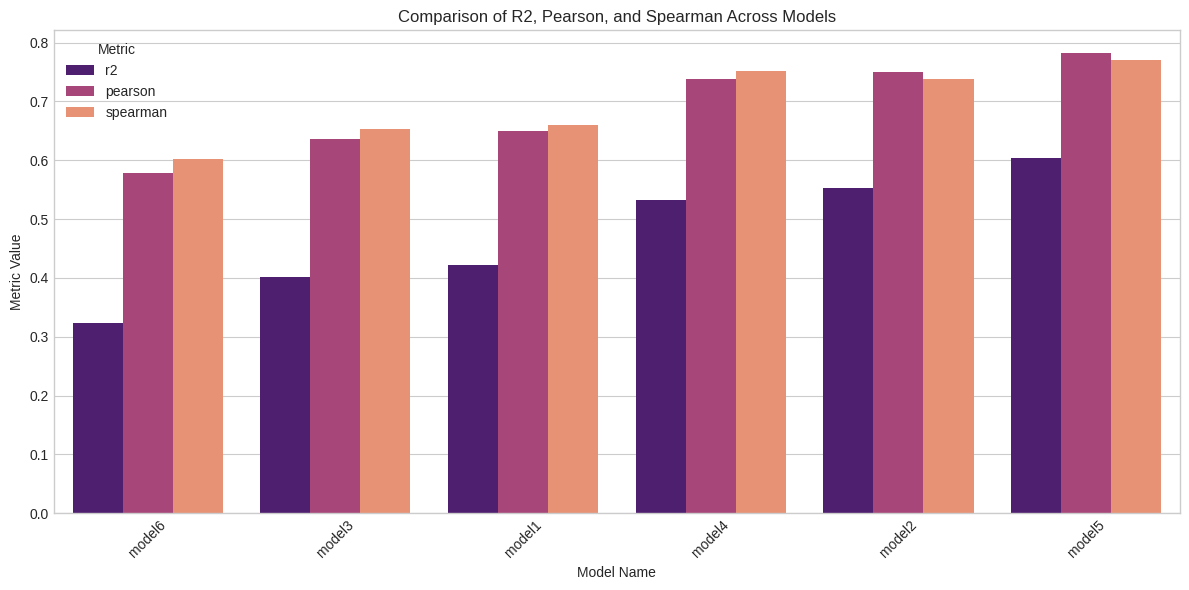

In [ ]:

# R2, Pearson, Spearman

# Sort by r2 for ordering
metrics_for_plot2 = ['model_name', 'r2', 'pearson', 'spearman']
df_plot2 = model_metrics[metrics_for_plot2].sort_values(by='r2', ascending=True)

# Melt the DataFrame
df_plot2_melted = df_plot2.melt(id_vars='model_name', var_name='Metric', value_name='Value')

fig2, ax2 = plt.subplots(figsize=(12, 6))
sns.barplot(x='model_name', y='Value', hue='Metric', data=df_plot2_melted, ax=ax2, palette='magma')
ax2.set_title('Comparison of R2, Pearson, and Spearman Across Models')
ax2.set_xlabel('Model Name')
ax2.set_ylabel('Metric Value')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Metric')
fig2.tight_layout()

# Save plot
filename2 = "model_metrics_r2_pearson_spearman_comparison.png"
output_path2 = os.path.join(PLOTS_BASE_PATH, filename2)
fig2.savefig(output_path2, dpi=300)
plt.show()

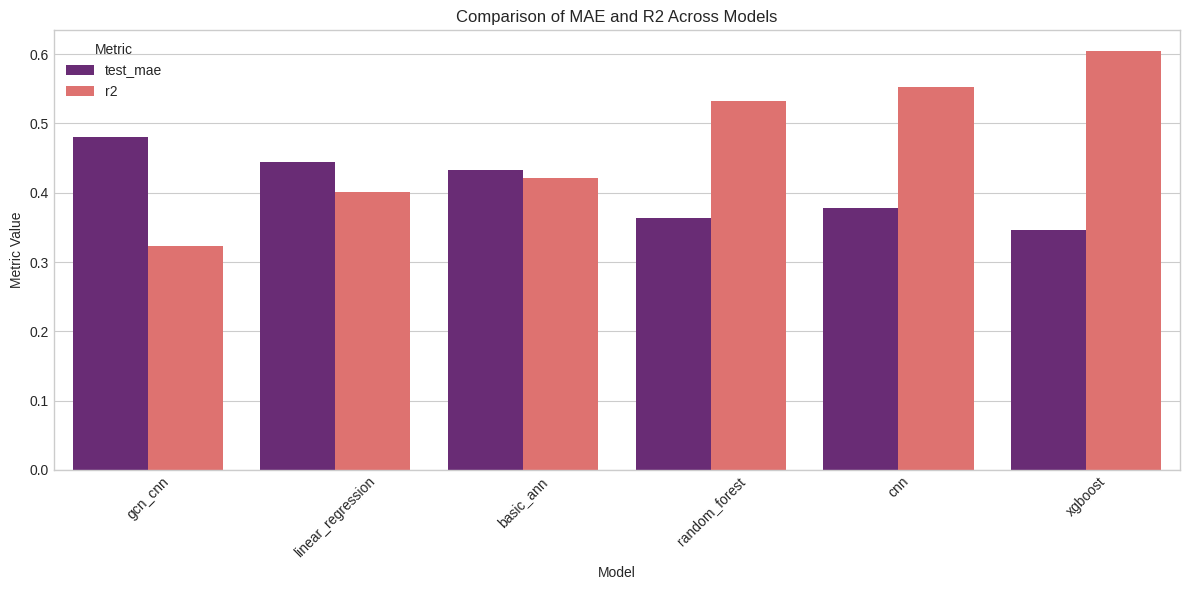

In [ ]:

# R2, MAE

# Sort by r2 for ordering
metrics_for_plot3 = ['model_type', 'test_mae', 'r2']
df_plot3 = model_metrics[metrics_for_plot3].sort_values(by='r2', ascending=True)

# Melt the DataFrame
df_plot3_melted = df_plot3.melt(id_vars='model_type', var_name='Metric', value_name='Value')

fig2, ax2 = plt.subplots(figsize=(12, 6))
sns.barplot(x='model_type', y='Value', hue='Metric', data=df_plot3_melted, ax=ax2, palette='magma')
ax2.set_title('Comparison of MAE and R2 Across Models')
ax2.set_xlabel('Model')
ax2.set_ylabel('Metric Value')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Metric')
fig2.tight_layout()

# Save plot
filename2 = "model_metrics_mae_r2_comparison.png"
output_path2 = os.path.join(PLOTS_BASE_PATH, filename2)
fig2.savefig(output_path2, dpi=300)
plt.show()